# 1D MHD in Dedalus with Adiabatic Closure

This notebook is a variant of the energy-evolving model where we **do not evolve total energy**.

The 1D ideal MHD equations for inviscid, compressible flow are:

$$\rho_t + (\rho u_1)_x = 0$$
$$(\rho u_i)_t + (\rho u_1 u_i + (p + B^2 / 2) \delta_{i1} - B_1 B_i)_x = 0$$
$$E_t + (u_1 (E + p + B^2 / 2) - B_1 (u \cdot B))_x = 0$$
$$(B_i)_t + (u_1 B_i - u_i B_1)_x = 0$$


Instead, pressure is imposed from an adiabatic closure:

$$p = K\rho^\gamma,$$

with $K=1$ in this notebook. The evolved variables are:

$$Q=[\rho,m_x,m_y,m_z,B_x,B_y,B_z],\qquad m_i=\rho u_i.$$

In [31]:
import numpy as np
import dedalus.public as d3

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

## Domain and fields

In [32]:
# Parameters
gamma = 3.0
K_adi = 1.0
N = 512
Lx = 8.0  # domain [-4, 4]

xcoord = d3.Coordinate('x')
dist = d3.Distributor(xcoord, dtype=np.float64)
xbasis = d3.RealFourier(xcoord, size=N, bounds=(-Lx/2, Lx/2), dealias=3/2)
x = dist.local_grid(xbasis)

rho = dist.Field(name='rho', bases=xbasis)
mx = dist.Field(name='mx', bases=xbasis)
my = dist.Field(name='my', bases=xbasis)
mz = dist.Field(name='mz', bases=xbasis)
Bx = dist.Field(name='Bx', bases=xbasis)
By = dist.Field(name='By', bases=xbasis)
Bz = dist.Field(name='Bz', bases=xbasis)

dx = lambda A: d3.Differentiate(A, xcoord)

rho_floor = 1e-12
rho_safe = rho + rho_floor
ux = mx / rho_safe
uy = my / rho_safe
uz = mz / rho_safe
B2 = Bx*Bx + By*By + Bz*Bz
p = K_adi * (rho_safe**gamma)

## 1D MHD equations with imposed adiabatic pressure

We evolve
$$
\partial_t Q + \partial_x F(Q) = S_{\mathrm{diss}},
\qquad
Q=[\rho,m_x,m_y,m_z,B_x,B_y,B_z],\quad m_i=\rho u_i,
$$
with imposed closure
$$
p = K\rho^\gamma.
$$

There is **no evolved total-energy equation** in this model.

## 1D equations used in this notebook (adiabatic closure + viscous/resistive terms)

### Ideal (hyperbolic) fluxes
$$
\begin{aligned}
F_{\rho} &= m_x,\\
F_{m_x} &= m_x u_x + p + \frac{B^2}{2} - B_x^2,\\
F_{m_y} &= m_y u_x - B_x B_y,\\
F_{m_z} &= m_z u_x - B_x B_z,\\
F_{B_x} &= 0,\\
F_{B_y} &= u_x B_y - u_y B_x,\\
F_{B_z} &= u_x B_z - u_z B_x,
\end{aligned}
$$
where
$$
B^2 = B_x^2 + B_y^2 + B_z^2.
$$

### Dissipation model
- viscosity coefficient: $\mu_{\mathrm{visc}}$
- resistivity: $\eta$

$$
\tau_{xx} = \frac{4}{3}\mu_{\mathrm{visc}}\,\partial_x u_x,\qquad
\tau_{xy} = \mu_{\mathrm{visc}}\,\partial_x u_y,\qquad
\tau_{xz} = \mu_{\mathrm{visc}}\,\partial_x u_z.
$$

### PDE system solved
$$
\begin{aligned}
\partial_t \rho &= -\partial_x(F_\rho),\\
\partial_t m_x &= -\partial_x(F_{m_x} - \tau_{xx}),\\
\partial_t m_y &= -\partial_x(F_{m_y} - \tau_{xy}),\\
\partial_t m_z &= -\partial_x(F_{m_z} - \tau_{xz}),\\
\partial_t B_x &= -\partial_x(F_{B_x}) + \eta\,\partial_{xx}B_x,\\
\partial_t B_y &= -\partial_x(F_{B_y}) + \eta\,\partial_{xx}B_y,\\
\partial_t B_z &= -\partial_x(F_{B_z}) + \eta\,\partial_{xx}B_z.
\end{aligned}
$$

So this run is a **7-variable non-ideal MHD system** with adiabatic pressure closure, viscous momentum diffusion, and resistive magnetic diffusion.


In [33]:
# Ideal MHD flux pieces with adiabatic closure
Frho = mx
Fmx = mx*ux + p + 0.5*B2 - Bx*Bx
Fmy = my*ux - Bx*By
Fmz = mz*ux - Bx*Bz
FBx = 0*Bx
FBy = ux*By - uy*Bx
FBz = ux*Bz - uz*Bx

# Dissipation coefficients
mu_visc = 2.0e-3
eta = 2.0e-3

dux_dx = dx(ux)
duy_dx = dx(uy)
duz_dx = dx(uz)
tau_xx = (4.0/3.0) * mu_visc * dux_dx
tau_xy = mu_visc * duy_dx
tau_xz = mu_visc * duz_dx

problem_namespace = dict(locals())
problem_namespace.pop('dt', None)

problem = d3.IVP([rho, mx, my, mz, Bx, By, Bz], namespace=problem_namespace)
problem.add_equation("dt(rho) = -dx(Frho)")
problem.add_equation("dt(mx)  = -dx(Fmx - tau_xx)")
problem.add_equation("dt(my)  = -dx(Fmy - tau_xy)")
problem.add_equation("dt(mz)  = -dx(Fmz - tau_xz)")
problem.add_equation("dt(Bx)  = -dx(FBx) + eta*dx(dx(Bx))")
problem.add_equation("dt(By)  = -dx(FBy) + eta*dx(dx(By))")
problem.add_equation("dt(Bz)  = -dx(FBz) + eta*dx(dx(Bz))")

solver = problem.build_solver(d3.RK222)
solver.stop_sim_time = 4.0

2026-02-21 22:09:12,504 subsystems 0/1 INFO :: Building subproblem matrices 1/1 (~100%) Elapsed: 0s, Remaining: 0s, Rate: 2.4e+01/s


## Initial condition

In [34]:
current_scale = rho['g'].shape[0] / N
x_ic = dist.local_grid(xbasis, scale=current_scale)

EPS = 0.1
EPS2 = 0.02
K = 6
SIGMA = 0.5

rho0 = 1 + EPS2*np.sin(K*x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2)) - EPS*np.exp(-((x_ic+3)**2)/(2*SIGMA**2))
p0 = K_adi * (np.maximum(rho0, 1e-12)**gamma)

Bx0 = 1 + EPS2*np.sin(K*x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2))
By0 = 1 + EPS2*np.sin(K*x_ic) + EPS*np.exp(-(x_ic**2)/(2*SIGMA**2))
Bz0 = np.ones_like(x_ic)

ux0 = np.zeros_like(x_ic)
uy0 = np.zeros_like(x_ic)
uz0 = np.zeros_like(x_ic)

rho['g'] = rho0
mx['g'] = rho0 * ux0
my['g'] = rho0 * uy0
mz['g'] = rho0 * uz0
Bx['g'] = Bx0
By['g'] = By0
Bz['g'] = Bz0

x_init_profile = x_ic.copy()
rho_init_profile = rho0.copy()
Bx_init_profile = Bx0.copy()
By_init_profile = By0.copy()
p_init_profile = p0.copy()

print('Initial condition set')

Initial condition set


## Time stepping, CFL, and HDF5 outputs

This run uses Dedalus built-ins for both stability control and data output:

- `d3.CFL(...)` computes an adaptive timestep from a velocity field.
- `solver.evaluator.add_file_handler(...)` writes analysis tasks directly to HDF5 (Tutorial 4 style).

For CFL diagnostics we track
$$\Delta t \le C_{\mathrm{CFL}}\,\frac{\Delta x}{\max_x\left(|u_x| + c_f\right)}$$
in sampled arrays for plotting, while full field snapshots are written to `.h5` files rather than appended in Python lists.

In [35]:
save_every = 10
diag_every = 20
print_every = 100

cfl_safety = 0.30
dt_min = 1e-6
dt_max = 2e-3
dx_grid = Lx / N

apply_filter_every = 20
filter_scale = 0.92

output_dir = Path('analysis_mhd_adiabatic')
if output_dir.exists():
    shutil.rmtree(output_dir)

analysis = solver.evaluator.add_file_handler(str(output_dir), iter=save_every, max_writes=800)
analysis.add_tasks(solver.state, layout='g')
analysis.add_task(mx / (rho + rho_floor), layout='g', name='ux')
analysis.add_task(K_adi * ((rho + rho_floor)**gamma), layout='g', name='p')

u_vec = dist.VectorField(xcoord, name='u_vec', bases=xbasis)
current_scale = mx['g'].shape[0] / N
u_vec.change_scales(current_scale)

CFL = d3.CFL(
    solver,
    initial_dt=dt_max,
    cadence=1,
    safety=cfl_safety,
    max_dt=dt_max,
    min_dt=dt_min,
    max_change=1.1,
    min_change=0.5,
    threshold=0.05,
)
CFL.add_velocity(u_vec)

# Characteristic-speed proxy for diagnostics
cf_expr = np.sqrt(gamma * (K_adi * ((rho + rho_floor)**gamma)) / (rho + rho_floor) + (Bx*Bx + By*By + Bz*Bz) / (rho + rho_floor))
fast_speed_expr = np.abs(mx / (rho + rho_floor)) + cf_expr
flow = d3.GlobalFlowProperty(solver, cadence=diag_every)
flow.add_property(fast_speed_expr, name='char_speed')

iter_diag, t_diag, dt_diag, cfl_diag, maxspeed_diag = [], [], [], [], []

while solver.proceed:
    rho_now = np.maximum(rho['g'], 1e-12)
    u_vec['g'][0] = mx['g'] / rho_now

    dt_step = CFL.compute_timestep()
    solver.step(dt_step)

    if solver.iteration % apply_filter_every == 0:
        for fld in [rho, mx, my, mz, Bx, By, Bz]:
            fld.low_pass_filter(scales=filter_scale)

    if solver.iteration % print_every == 0:
        max_speed = flow.max('char_speed')
        cfl_eff = max_speed * dt_step / dx_grid
        print(f"iter={solver.iteration:6d}  t={solver.sim_time:.5f}  dt={dt_step:.2e}  CFL={cfl_eff:.3f}  max|u|+cf={max_speed:.3f}")

    if solver.iteration % diag_every == 0 or not solver.proceed:
        max_speed = flow.max('char_speed')
        cfl_eff = max_speed * dt_step / dx_grid
        iter_diag.append(solver.iteration)
        t_diag.append(solver.sim_time)
        dt_diag.append(dt_step)
        cfl_diag.append(cfl_eff)
        maxspeed_diag.append(max_speed)

analysis_files = sorted(output_dir.glob('analysis_mhd_adiabatic_s*.h5'))
print(f"Finished: iter={solver.iteration}, t={solver.sim_time:.4f}")
print(f"Wrote {len(analysis_files)} analysis set file(s) under: {output_dir}/")

iter=   100  t=0.20000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.602
iter=   200  t=0.40000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.602
iter=   300  t=0.60000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.599
iter=   400  t=0.80000  dt=2.00e-03  CFL=0.334  max|u|+cf=2.608
iter=   500  t=1.00000  dt=2.00e-03  CFL=0.336  max|u|+cf=2.623
iter=   600  t=1.20000  dt=2.00e-03  CFL=0.332  max|u|+cf=2.596
iter=   700  t=1.40000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.599
iter=   800  t=1.60000  dt=2.00e-03  CFL=0.333  max|u|+cf=2.605
iter=   900  t=1.80000  dt=2.00e-03  CFL=0.330  max|u|+cf=2.581
iter=  1000  t=2.00000  dt=2.00e-03  CFL=0.330  max|u|+cf=2.581
iter=  1100  t=2.20000  dt=2.00e-03  CFL=0.332  max|u|+cf=2.596
iter=  1200  t=2.40000  dt=2.00e-03  CFL=0.335  max|u|+cf=2.617
iter=  1300  t=2.60000  dt=2.00e-03  CFL=0.336  max|u|+cf=2.626
iter=  1400  t=2.80000  dt=2.00e-03  CFL=0.334  max|u|+cf=2.606
iter=  1500  t=3.00000  dt=2.00e-03  CFL=0.331  max|u|+cf=2.585
iter=  1600  t=3.20000  dt=2.00e-03  CFL

## What gets saved and what is monitored

During the run:
- fields are written to `analysis_mhd_adiabatic/*.h5` through a Dedalus `FileHandler`,
- timestep is chosen by built-in `d3.CFL`,
- sampled diagnostics track iteration, time, `dt`, effective CFL, and a max characteristic-speed estimate.

After the run, plotting cells read the field history directly from the HDF5 sets.

In [36]:
from pathlib import Path
import h5py
# Quick HDF5 inspection: files, tasks, and time span
analysis_dir = Path('analysis_mhd_adiabatic')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_adiabatic_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run the time-stepping cell first.")
else:
    print(f"Found {len(analysis_files)} set file(s):")
    for fp in analysis_files:
        print(f"  - {fp}")

    with h5py.File(analysis_files[0], mode='r') as f0:
        task_names = list(f0['tasks'].keys())
    print("\nTasks in file handler:")
    for name in task_names:
        print(f"  - {name}")

    t_all = []
    for fp in analysis_files:
        with h5py.File(fp, mode='r') as f:
            t_all.append(np.asarray(f['tasks']['rho'].dims[0]['sim_time']))
    t_all = np.concatenate(t_all)

    print("\nTime coverage:")
    print(f"  writes: {len(t_all)}")
    print(f"  t_min: {t_all.min():.5f}")
    print(f"  t_max: {t_all.max():.5f}")
    if len(t_all) > 1:
        dtw = np.diff(t_all)
        print(f"  write dt range: [{dtw.min():.5e}, {dtw.max():.5e}]")

Found 1 set file(s):
  - analysis_mhd_adiabatic/analysis_mhd_adiabatic_s1.h5

Tasks in file handler:
  - Bx
  - By
  - Bz
  - mx
  - my
  - mz
  - p
  - rho
  - ux

Time coverage:
  writes: 201
  t_min: 0.00000
  t_max: 4.00000
  write dt range: [2.00000e-02, 2.00000e-02]


## Initial vs final comparison

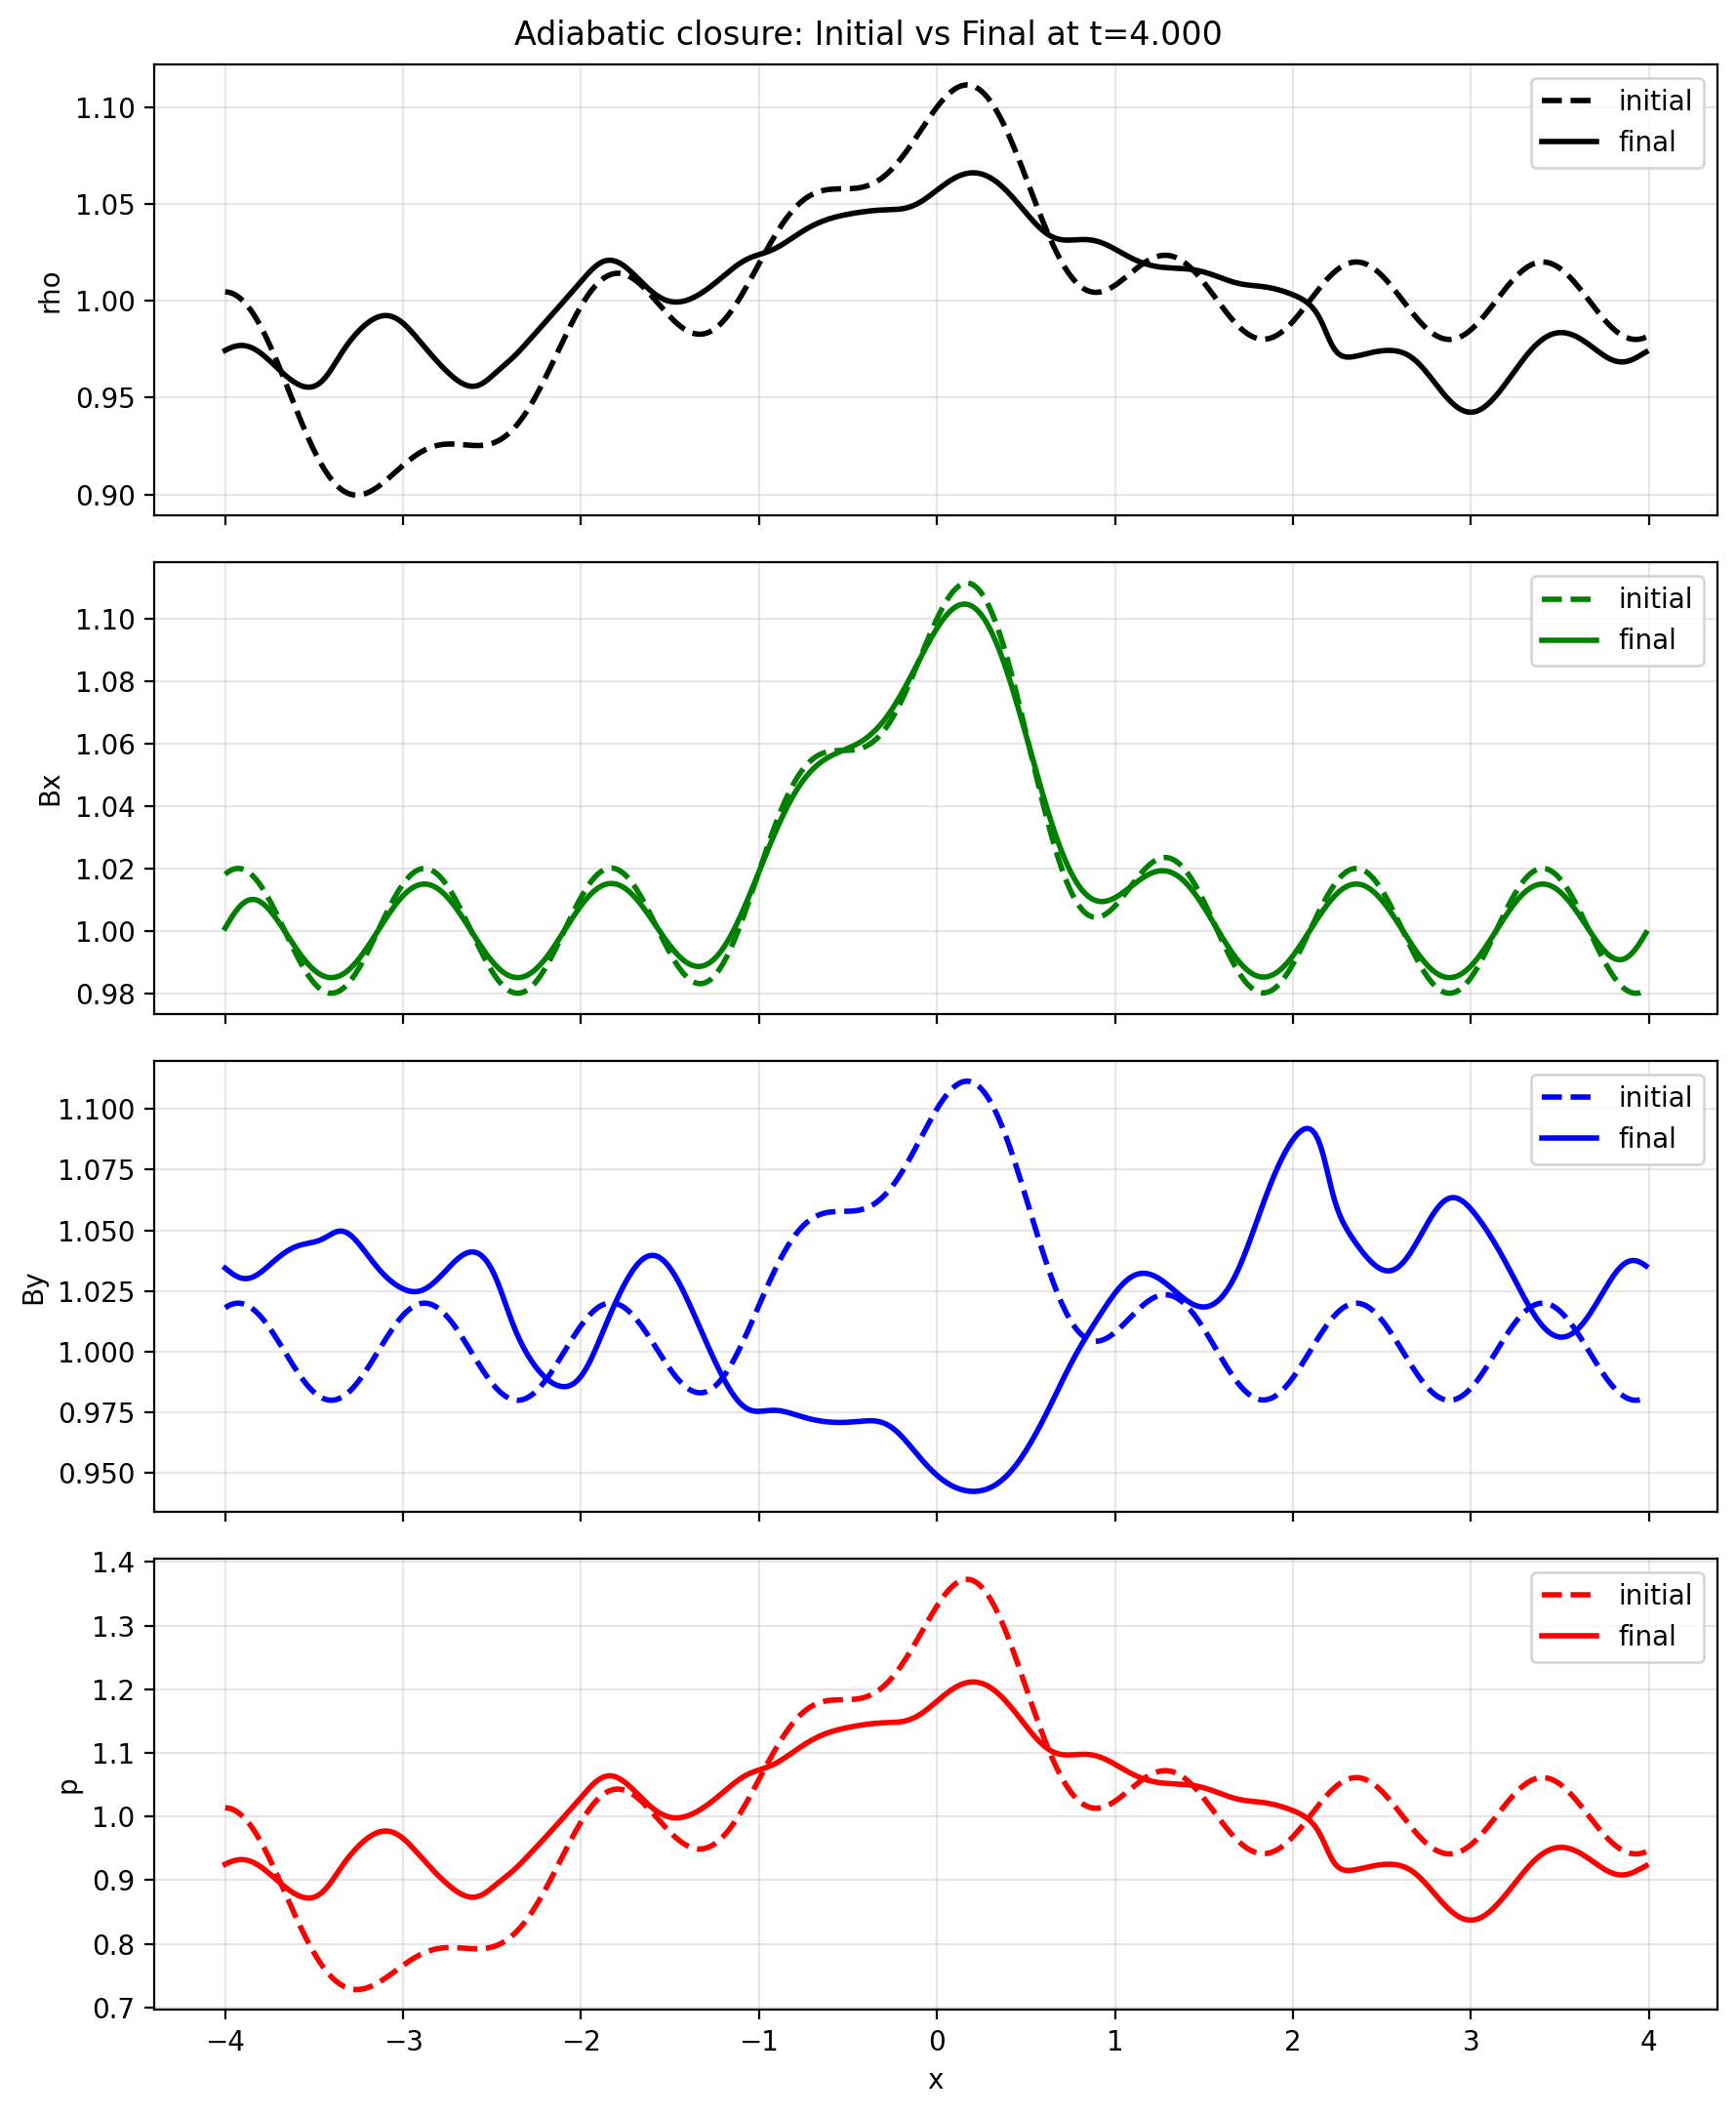

In [ ]:
import matplotlib.pyplot as plt
analysis_dir = Path('analysis_mhd_adiabatic')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_adiabatic_s*.h5'))

if len(analysis_files) == 0:
    print('No analysis HDF5 files found. Run the time-stepping cell first.')
else:
    with h5py.File(analysis_files[-1], mode='r') as f:
        rho_ds = f['tasks']['rho']
        x_final = np.asarray(rho_ds.dims[1][0])
        t_final = float(np.asarray(rho_ds.dims[0]['sim_time'])[-1])
        final_data = {name: np.real(np.asarray(f['tasks'][name][-1])) for name in ['rho', 'Bx', 'By', 'p']}

    x_init = np.asarray(x_init_profile)
    init_data = {
        'rho': np.asarray(rho_init_profile),
        'Bx': np.asarray(Bx_init_profile),
        'By': np.asarray(By_init_profile),
        'p': np.asarray(p_init_profile),
    }

    needs_interp = (len(x_init) != len(x_final)) or (np.max(np.abs(x_init - x_final)) > 1e-12)
    init_plot = {k: (np.interp(x_final, x_init, v) if needs_interp else v) for k, v in init_data.items()}

    plot_cfg = [('rho', 'k'), ('Bx', 'g'), ('By', 'b'), ('p', 'r')]
    fig, axes = plt.subplots(len(plot_cfg), 1, figsize=(9, 11), sharex=True)

    for ax, (name, color) in zip(axes, plot_cfg):
        ax.plot(x_final, init_plot[name], f'{color}--', lw=2, label='initial')
        ax.plot(x_final, final_data[name], f'{color}-', lw=2, label='final')
        ax.set_ylabel(name)
        ax.grid(alpha=0.3)
        ax.legend(loc='best')

    axes[-1].set_xlabel('x')
    plt.suptitle(f'Adiabatic closure: Initial vs Final at t={t_final:.3f}')
    plt.tight_layout()
    plt.show()

## CFL diagnostics

steps recorded: 101
final time: 4.00200
dt range: [2.00e-03, 2.00e-03]
CFL range: [0.330, 0.337]


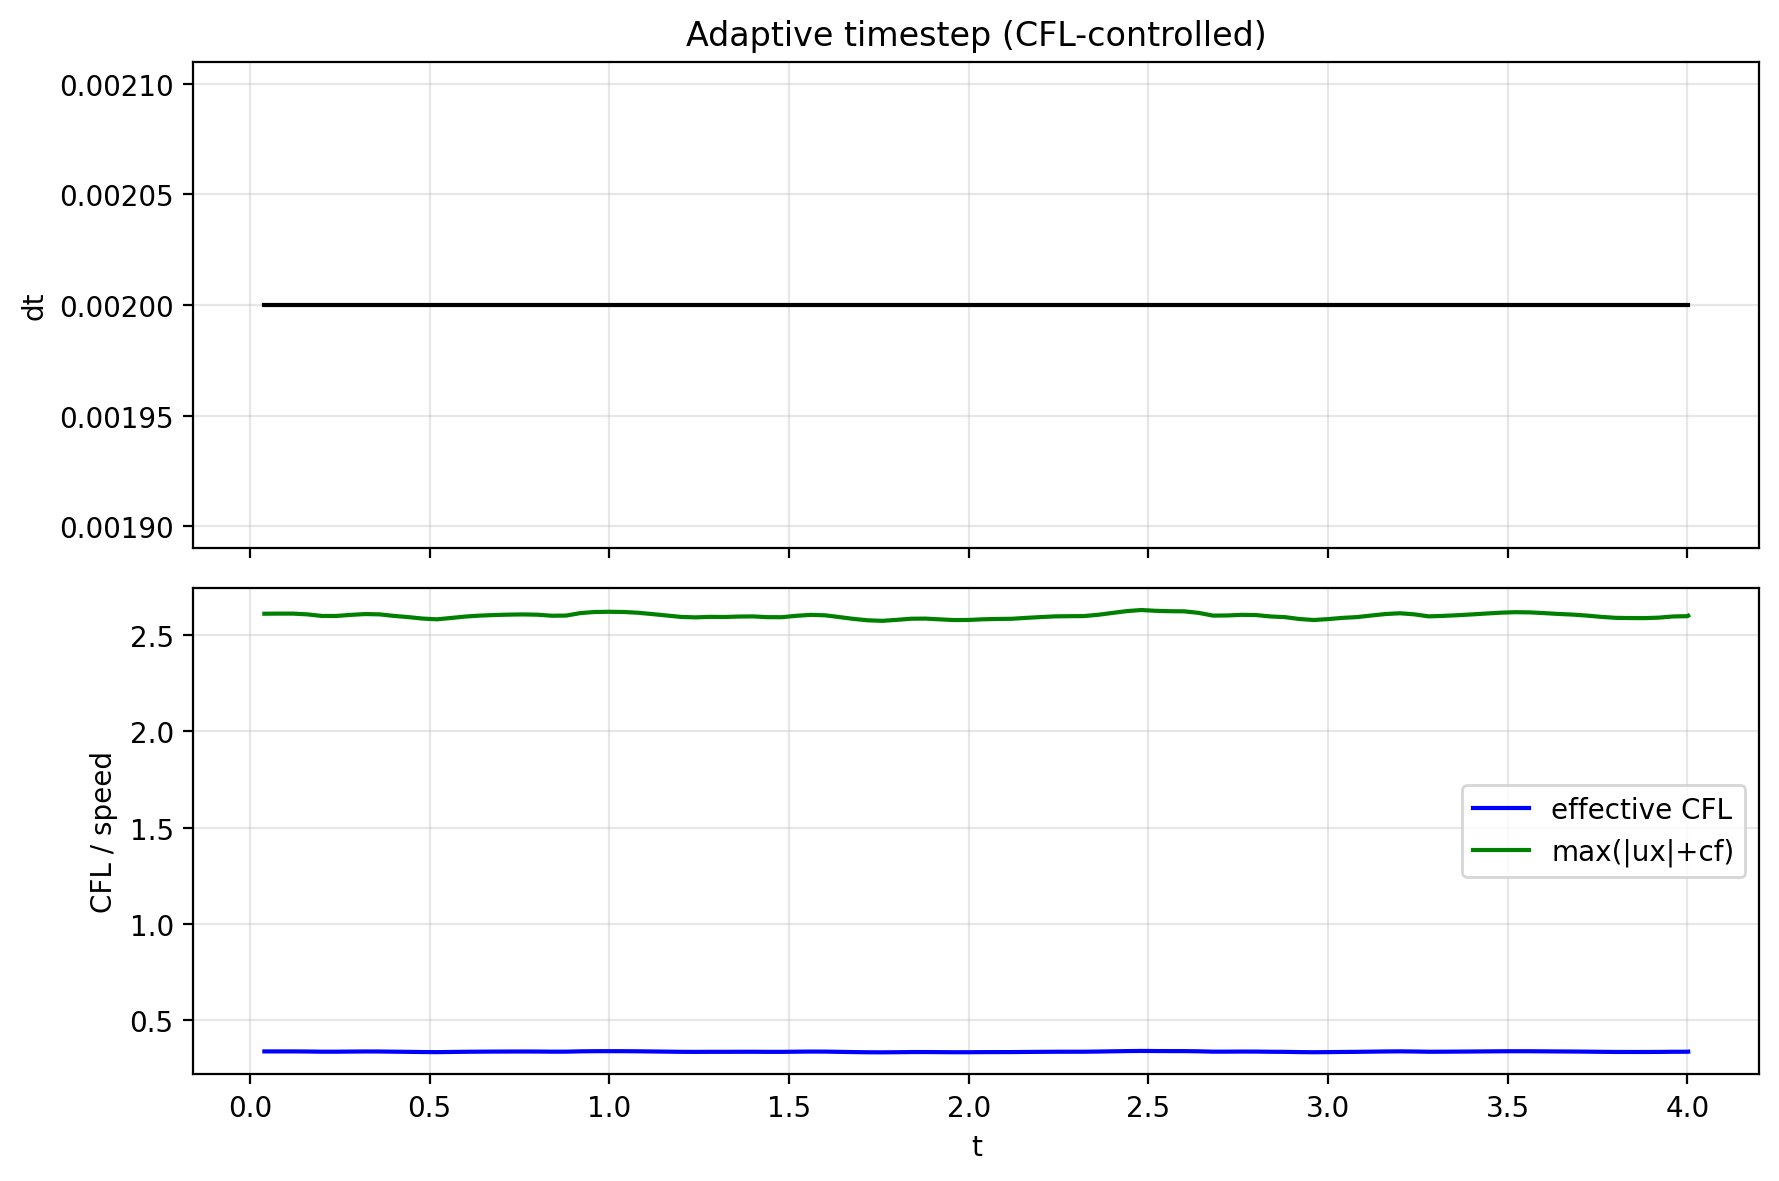

In [38]:
if len(t_diag) == 0:
    print('No timestep diagnostics found. Run the time-stepping cell first.')
else:
    print(f'steps recorded: {len(t_diag)}')
    print(f'final time: {t_diag[-1]:.5f}')
    print(f'dt range: [{np.min(dt_diag):.2e}, {np.max(dt_diag):.2e}]')
    print(f'CFL range: [{np.min(cfl_diag):.3f}, {np.max(cfl_diag):.3f}]')

    fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
    axes[0].plot(t_diag, dt_diag, 'k-')
    axes[0].set_ylabel('dt')
    axes[0].set_title('Adaptive timestep (CFL-controlled)')
    axes[0].grid(alpha=0.3)

    axes[1].plot(t_diag, cfl_diag, 'b-', label='effective CFL')
    axes[1].plot(t_diag, maxspeed_diag, 'g-', label='max(|ux|+cf)')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('CFL / speed')
    axes[1].legend(loc='best')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Space-time fields and energy-transfer diagnostics

This cell reads HDF5 outputs and provides:
- the original space-time field figure (fields vs $x,t$),
- an energy-transfer plot using $\Delta E_i(t)=E_i(t)-E_i(0)$ for kinetic, magnetic, thermal, and total energy,
- quick variation checks to confirm dynamics are loaded from HDF5 (not a fixed snapshot).

Relative variation from first write:
  rho: 1.316e-01
  ux : 1.563e+13
  By : 2.390e-01
  p  : 3.783e-01


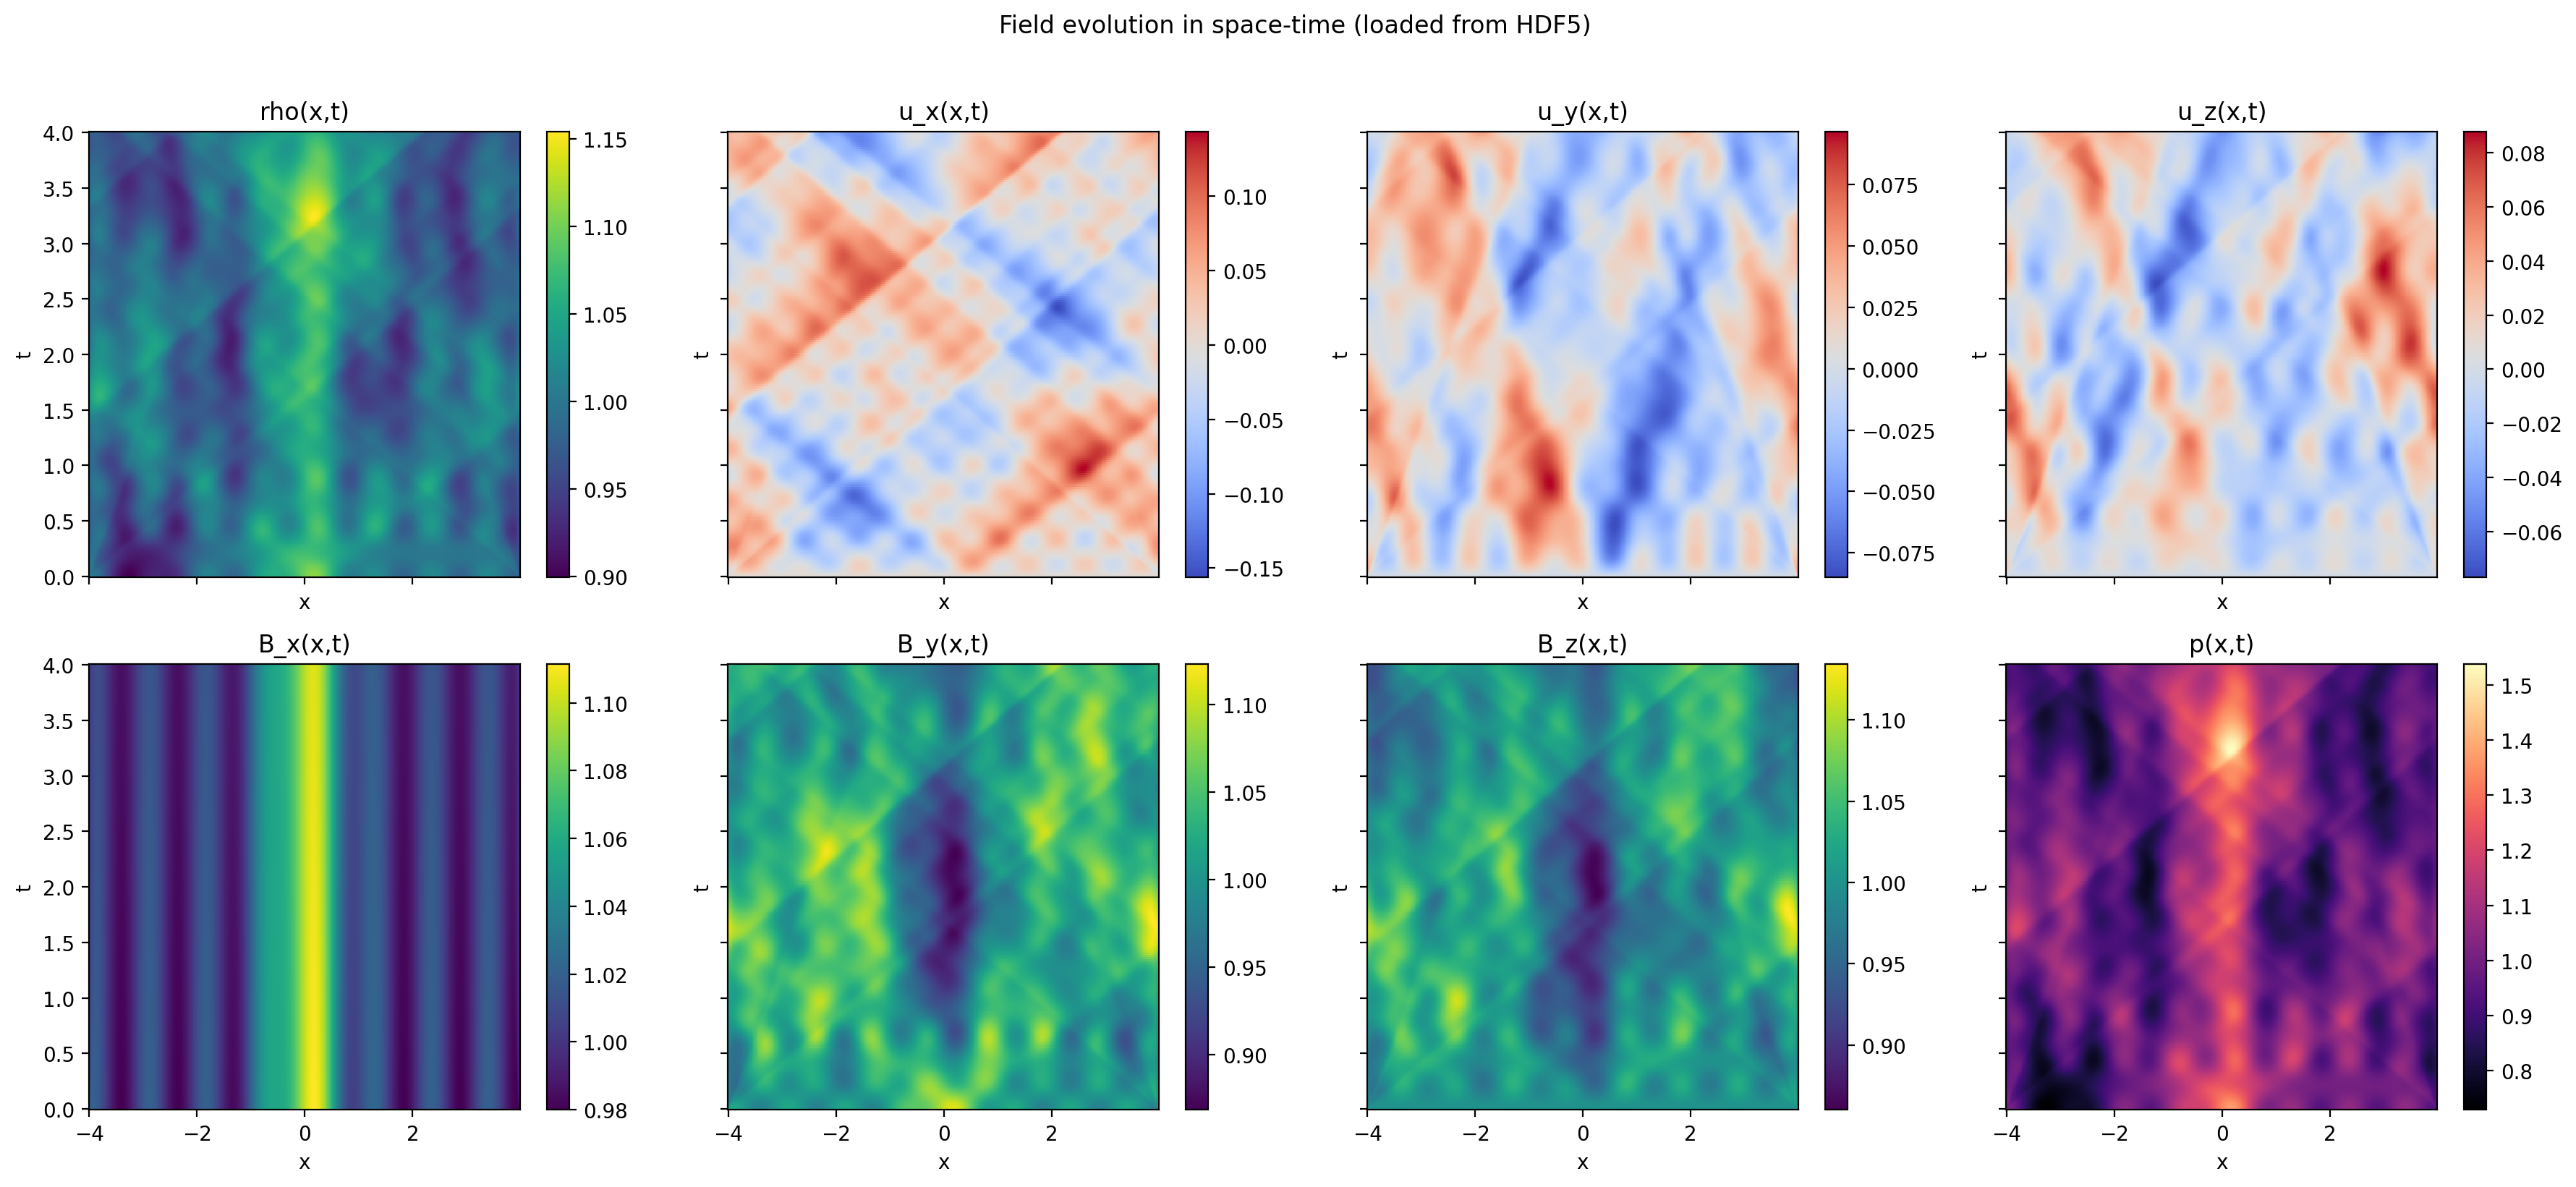

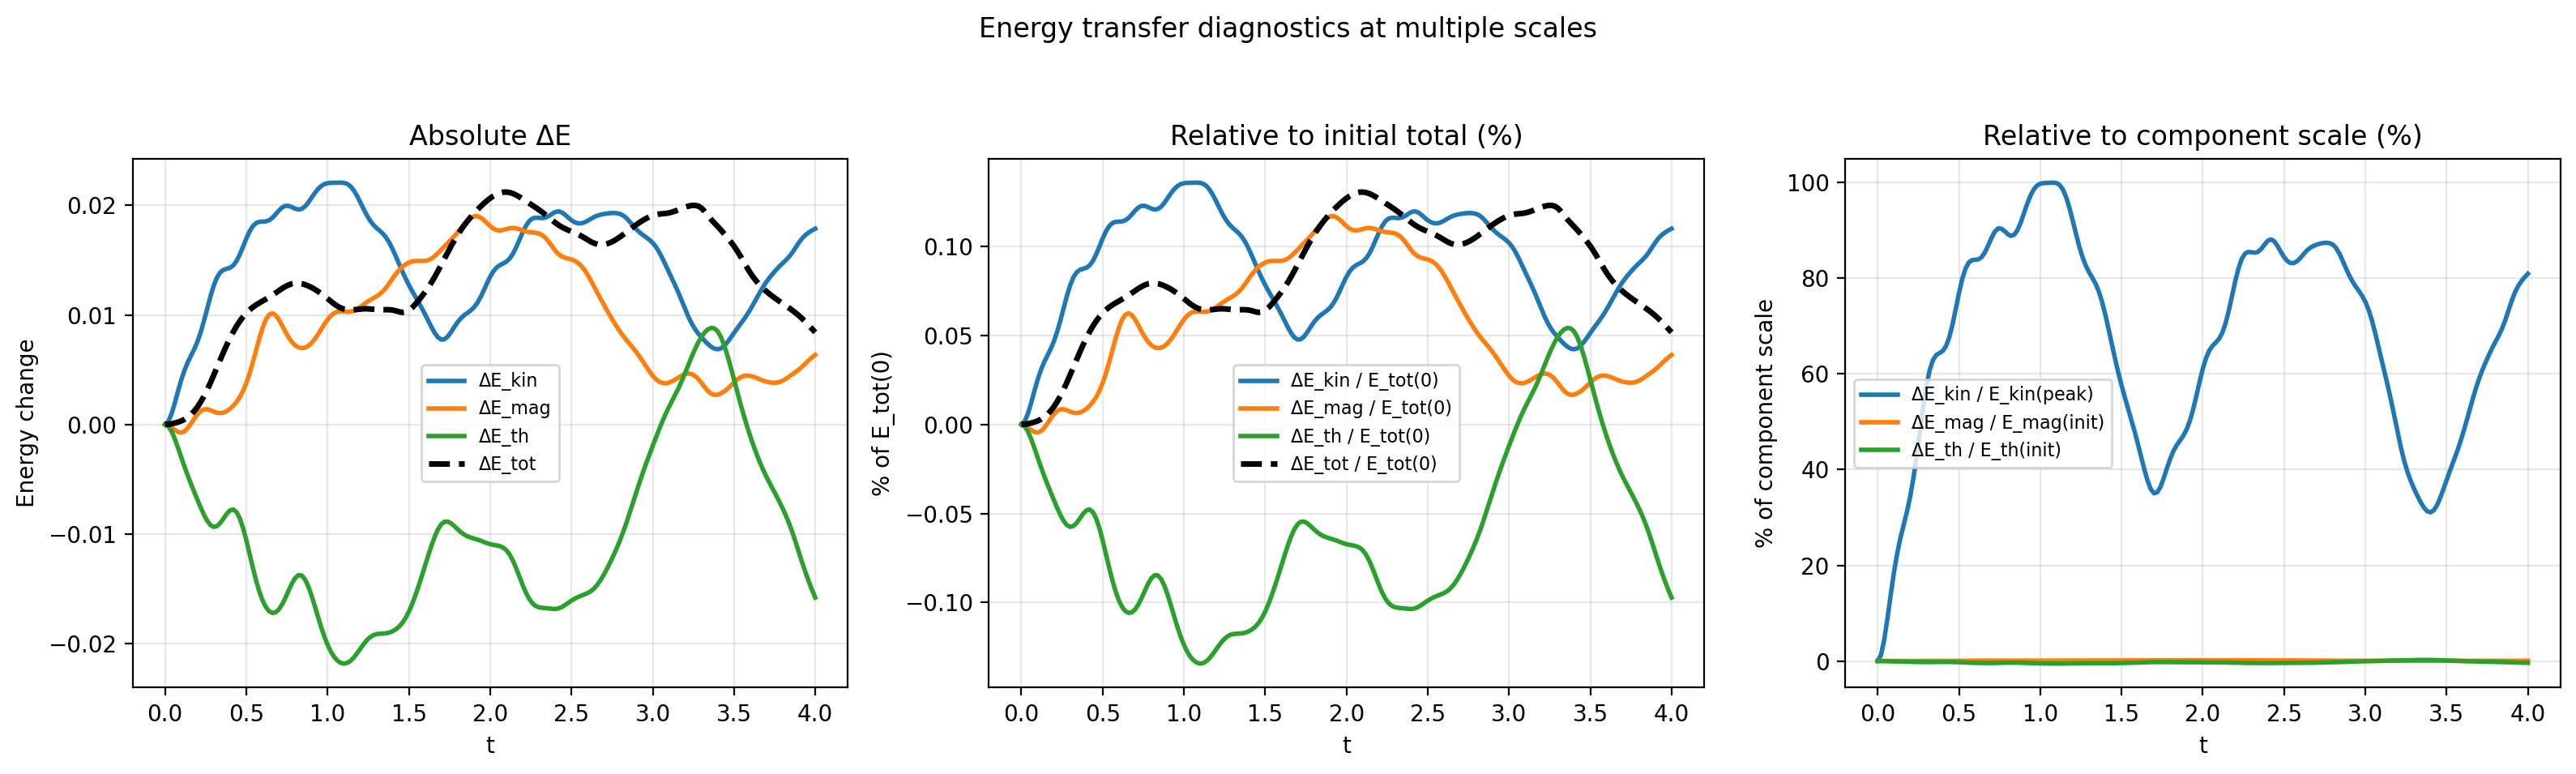

Initial E_tot: 1.62641519e+01
Final   E_tot: 1.62725617e+01
Final relative drift: 5.171e-04
Max |relative drift| over time: 1.305e-03
RMS relative drift over time: 9.061e-04

Component-transfer amplitudes:
  max |ΔE_kin| / E_tot(0): 1.358e-01%
  max |ΔE_mag| / E_tot(0): 1.169e-01%
  max |ΔE_th | / E_tot(0): 1.343e-01%
  max |ΔE_tot| / E_tot(0): 1.305e-01%
  component scales used: E_kin(peak)=2.208e-02, E_mag(init)=1.224e+01, E_th(init)=4.026e+00


In [46]:
# Space-time fields + energy-transfer diagnostics from HDF5 outputs
import matplotlib.pyplot as plt
analysis_dir = Path('analysis_mhd_adiabatic')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_adiabatic_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run the time-stepping cell first.")
else:
    def load_task_from_sets(task_name):
        t_list = []
        a_list = []
        x_vals = None

        for fp in analysis_files:
            with h5py.File(fp, mode='r') as f:
                ds = f['tasks'][task_name]
                data = np.asarray(ds)
                sim_t = np.asarray(ds.dims[0]['sim_time'])
                if data.ndim >= 2 and x_vals is None:
                    x_vals = np.asarray(ds.dims[1][0])
            t_list.append(sim_t)
            a_list.append(data)

        t_all = np.concatenate(t_list, axis=0)
        a_all = np.concatenate(a_list, axis=0)
        return np.real(t_all), np.real(a_all), np.real(x_vals)

    t_rho, rho_arr, x_plot = load_task_from_sets('rho')
    _, mx_arr, _ = load_task_from_sets('mx')
    _, my_arr, _ = load_task_from_sets('my')
    _, mz_arr, _ = load_task_from_sets('mz')
    _, bx_arr, _ = load_task_from_sets('Bx')
    _, by_arr, _ = load_task_from_sets('By')
    _, bz_arr, _ = load_task_from_sets('Bz')
    _, p_arr, _ = load_task_from_sets('p')

    n_common = min(
        len(t_rho), len(mx_arr), len(my_arr), len(mz_arr),
        len(bx_arr), len(by_arr), len(bz_arr), len(p_arr)
    )

    t_plot = t_rho[:n_common]
    rho_arr = np.maximum(rho_arr[:n_common], 1e-12)
    mx_arr = mx_arr[:n_common]
    my_arr = my_arr[:n_common]
    mz_arr = mz_arr[:n_common]
    bx_arr = bx_arr[:n_common]
    by_arr = by_arr[:n_common]
    bz_arr = bz_arr[:n_common]
    p_arr = np.maximum(np.nan_to_num(p_arr[:n_common], nan=0.0, posinf=0.0, neginf=0.0), 0.0)

    ux_arr = mx_arr / rho_arr
    uy_arr = my_arr / rho_arr
    uz_arr = mz_arr / rho_arr

    # Quick confirmation we are loading dynamics (not a fixed snapshot)
    def rel_variation(arr):
        baseline = np.maximum(np.mean(np.abs(arr[0])), 1e-14)
        return np.max(np.abs(arr - arr[0])) / baseline

    print("Relative variation from first write:")
    print(f"  rho: {rel_variation(rho_arr):.3e}")
    print(f"  ux : {rel_variation(ux_arr):.3e}")
    print(f"  By : {rel_variation(by_arr):.3e}")
    print(f"  p  : {rel_variation(p_arr):.3e}")

    # 1) Original space-time figure over x and t
    TT, XX = np.meshgrid(t_plot, x_plot, indexing='ij')
    fields = [
        ('rho(x,t)', rho_arr, 'viridis'),
        ('u_x(x,t)', ux_arr, 'coolwarm'),
        ('u_y(x,t)', uy_arr, 'coolwarm'),
        ('u_z(x,t)', uz_arr, 'coolwarm'),
        ('B_x(x,t)', bx_arr, 'viridis'),
        ('B_y(x,t)', by_arr, 'viridis'),
        ('B_z(x,t)', bz_arr, 'viridis'),
        ('p(x,t)', p_arr, 'magma'),
    ]

    fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
    axes_list = list(axes.flat)

    for ax, (title, arr, cmap) in zip(axes_list, fields):
        pcm = ax.pcolormesh(XX, TT, arr, shading='auto', cmap=cmap)
        ax.set_title(title)
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        fig.colorbar(pcm, ax=ax)

    plt.suptitle('Field evolution in space-time (loaded from HDF5)', y=1.02)
    plt.tight_layout()
    plt.show()

    # 2) Energy transfer diagnostics
    kinetic_density = 0.5 * (mx_arr**2 + my_arr**2 + mz_arr**2) / rho_arr
    magnetic_density = 0.5 * (bx_arr**2 + by_arr**2 + bz_arr**2)
    thermal_density = p_arr / max(gamma - 1.0, 1e-12)

    E_kin = np.trapezoid(kinetic_density, x_plot, axis=1)
    E_mag = np.trapezoid(magnetic_density, x_plot, axis=1)
    E_th = np.trapezoid(thermal_density, x_plot, axis=1)
    E_tot = E_kin + E_mag + E_th

    dE_kin = E_kin - E_kin[0]
    dE_mag = E_mag - E_mag[0]
    dE_th = E_th - E_th[0]
    dE_tot = E_tot - E_tot[0]

    E0 = max(abs(E_tot[0]), 1e-14)

    def robust_component_scale(E_comp):
        e_init = abs(E_comp[0])
        e_peak = np.max(np.abs(E_comp))
        if e_init < 1e-6 * max(e_peak, 1e-14):
            return max(e_peak, 1e-14), 'peak'
        return max(e_init, 1e-14), 'init'

    kin_scale, kin_scale_mode = robust_component_scale(E_kin)
    mag_scale, mag_scale_mode = robust_component_scale(E_mag)
    th_scale, th_scale_mode = robust_component_scale(E_th)

    # Relative-to-total and relative-to-own-component views
    dE_kin_pct_tot = 100.0 * dE_kin / E0
    dE_mag_pct_tot = 100.0 * dE_mag / E0
    dE_th_pct_tot = 100.0 * dE_th / E0
    dE_tot_pct_tot = 100.0 * dE_tot / E0

    dE_kin_pct_own = 100.0 * dE_kin / kin_scale
    dE_mag_pct_own = 100.0 * dE_mag / mag_scale
    dE_th_pct_own = 100.0 * dE_th / th_scale

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharex=True)

    # Absolute drift
    axes[0].plot(t_plot, dE_kin, label='ΔE_kin', lw=2)
    axes[0].plot(t_plot, dE_mag, label='ΔE_mag', lw=2)
    axes[0].plot(t_plot, dE_th, label='ΔE_th', lw=2)
    axes[0].plot(t_plot, dE_tot, label='ΔE_tot', lw=2.5, linestyle='--', color='k')
    axes[0].set_title('Absolute ΔE')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('Energy change')
    axes[0].grid(alpha=0.3)
    axes[0].legend(loc='best', fontsize=8)

    # Relative to initial total energy
    axes[1].plot(t_plot, dE_kin_pct_tot, label='ΔE_kin / E_tot(0)', lw=2)
    axes[1].plot(t_plot, dE_mag_pct_tot, label='ΔE_mag / E_tot(0)', lw=2)
    axes[1].plot(t_plot, dE_th_pct_tot, label='ΔE_th / E_tot(0)', lw=2)
    axes[1].plot(t_plot, dE_tot_pct_tot, label='ΔE_tot / E_tot(0)', lw=2.5, linestyle='--', color='k')
    axes[1].set_title('Relative to initial total (%)')
    axes[1].set_xlabel('t')
    axes[1].set_ylabel('% of E_tot(0)')
    axes[1].grid(alpha=0.3)
    axes[1].legend(loc='best', fontsize=8)

    # Relative to each component scale (initial unless near-zero, then peak)
    axes[2].plot(t_plot, dE_kin_pct_own, label=f'ΔE_kin / E_kin({kin_scale_mode})', lw=2)
    axes[2].plot(t_plot, dE_mag_pct_own, label=f'ΔE_mag / E_mag({mag_scale_mode})', lw=2)
    axes[2].plot(t_plot, dE_th_pct_own, label=f'ΔE_th / E_th({th_scale_mode})', lw=2)
    axes[2].set_title('Relative to component scale (%)')
    axes[2].set_xlabel('t')
    axes[2].set_ylabel('% of component scale')
    axes[2].grid(alpha=0.3)
    axes[2].legend(loc='best', fontsize=8)

    plt.suptitle('Energy transfer diagnostics at multiple scales', y=1.05)
    plt.tight_layout()
    plt.show()

    # 3) Total-energy conservation metrics (relative to initial total energy)
    rel_tot = dE_tot / E0
    final_rel = rel_tot[-1]
    max_abs_rel = np.max(np.abs(rel_tot))
    rms_rel = np.sqrt(np.mean(rel_tot**2))

    print(f"Initial E_tot: {E_tot[0]:.8e}")
    print(f"Final   E_tot: {E_tot[-1]:.8e}")
    print(f"Final relative drift: {final_rel:.3e}")
    print(f"Max |relative drift| over time: {max_abs_rel:.3e}")
    print(f"RMS relative drift over time: {rms_rel:.3e}")

    print("\nComponent-transfer amplitudes:")
    print(f"  max |ΔE_kin| / E_tot(0): {np.max(np.abs(dE_kin_pct_tot)):.3e}%")
    print(f"  max |ΔE_mag| / E_tot(0): {np.max(np.abs(dE_mag_pct_tot)):.3e}%")
    print(f"  max |ΔE_th | / E_tot(0): {np.max(np.abs(dE_th_pct_tot)):.3e}%")
    print(f"  max |ΔE_tot| / E_tot(0): {np.max(np.abs(dE_tot_pct_tot)):.3e}%")
    print("  component scales used: "
          f"E_kin({kin_scale_mode})={kin_scale:.3e}, "
          f"E_mag({mag_scale_mode})={mag_scale:.3e}, "
          f"E_th({th_scale_mode})={th_scale:.3e}")

## Pressure-density, ML closure, and dispersion diagnostics

This section mirrors the original notebook post-processing style:
- pressure vs density scatter,
- MLP training for pressure prediction from $(\rho, u_x, u_y, u_z, B_x, B_y, B_z)$,
- prediction-quality plots,
- Jacobian/eigenvalue-based dispersion diagnostics from the learned closure.

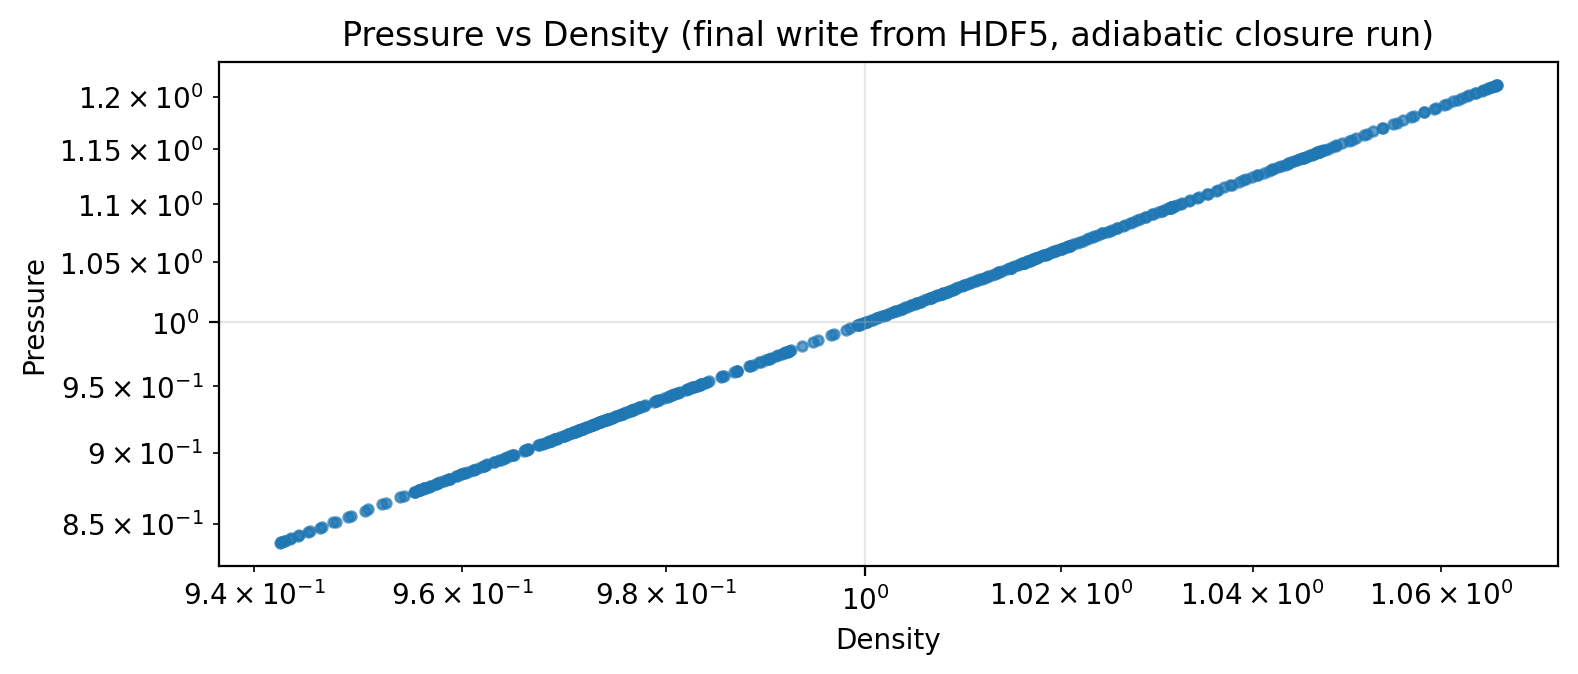

In [23]:
# Pressure vs density scatter (from final HDF5 write)
analysis_dir = Path('analysis_mhd_adiabatic')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_adiabatic_s*.h5'))

if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run the time-stepping cell first.")
else:
    with h5py.File(analysis_files[-1], mode='r') as f:
        rho_plot = np.real(np.asarray(f['tasks']['rho'][-1]))
        p_plot = np.real(np.asarray(f['tasks']['p'][-1]))

    rho_plot = np.maximum(np.nan_to_num(rho_plot, nan=1e-12, posinf=1e-12, neginf=1e-12), 1e-12)
    p_plot = np.maximum(np.nan_to_num(p_plot, nan=1e-12, posinf=1e-12, neginf=1e-12), 1e-12)

    plt.figure(figsize=(8, 3.5))
    plt.scatter(rho_plot, p_plot, s=12, alpha=0.7)
    plt.xlabel('Density')
    plt.ylabel('Pressure')
    plt.xscale('log')
    plt.yscale('log')
    plt.title('Pressure vs Density (final write from HDF5, adiabatic closure run)')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Network choice and regularization rationale

The pressure closure is modeled with a compact **MLP** that maps
$$
(\rho, u_x, u_y, u_z, B_x, B_y, B_z)\ \rightarrow\ p.
$$

### Why this network?
- **Fully connected MLP** is appropriate because each sample is a local state vector (no spatial stencil required).
- **Three hidden layers (32 units each)** provide enough nonlinearity for MHD thermodynamic coupling without becoming overly large.
- **`tanh` activations** are smooth and bounded, helping represent continuous constitutive behavior and stabilizing Jacobian-based analyses.
- **Small model size** improves robustness and reduces overfitting risk for moderate dataset size.

### Why normalization?
- Inputs and target pressure are standardized using **training-split statistics only**.
- This keeps features on comparable scales, improves optimizer conditioning, and prevents leakage.

### Regularization and stability controls
- **Dropout (0.10)**
- **AdamW with weight decay (`1e-4`)**
- **One-cycle cosine learning-rate schedule**
- **Gradient clipping (`max_norm=1.0`)**
- **Early stopping (patience-based)**

### Time-aware validation design
- Train/test split is **chronological** (first 80% writes for training, final 20% for testing).

In [24]:
# ML training with TIME-ORDERED split + normalization
# Train on first 80% of time writes, test on final 20%

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

analysis_dir = Path('analysis_mhd_adiabatic')
analysis_files = sorted(analysis_dir.glob('analysis_mhd_adiabatic_s*.h5'))
if len(analysis_files) == 0:
    print("No analysis HDF5 files found. Run the time-stepping cell first.")
else:
    def load_task_from_sets(task_name):
        t_list = []
        a_list = []
        for fp in analysis_files:
            with h5py.File(fp, mode='r') as f:
                ds = f['tasks'][task_name]
                a_list.append(np.real(np.asarray(ds)))
                t_list.append(np.asarray(ds.dims[0]['sim_time']))
        t_all = np.concatenate(t_list, axis=0)
        a_all = np.concatenate(a_list, axis=0)
        return np.real(t_all), np.real(a_all)

    # Load full time history
    t_all, rho_all = load_task_from_sets('rho')
    _, mx_all = load_task_from_sets('mx')
    _, my_all = load_task_from_sets('my')
    _, mz_all = load_task_from_sets('mz')
    _, bx_all = load_task_from_sets('Bx')
    _, by_all = load_task_from_sets('By')
    _, bz_all = load_task_from_sets('Bz')
    _, p_all = load_task_from_sets('p')

    rho_safe = np.maximum(rho_all, 1e-12)
    ux_all = mx_all / rho_safe
    uy_all = my_all / rho_safe
    uz_all = mz_all / rho_safe

    X_all = np.stack([rho_safe, ux_all, uy_all, uz_all, bx_all, by_all, bz_all], axis=-1)
    y_all = p_all[..., None]

    n_time = X_all.shape[0]
    n_train_time = max(1, int(0.8 * n_time))
    n_train_time = min(n_train_time, n_time - 1) if n_time > 1 else 1

    X_train_raw = X_all[:n_train_time].reshape(-1, 7)
    y_train_raw = y_all[:n_train_time].reshape(-1, 1)
    X_test_raw = X_all[n_train_time:].reshape(-1, 7)
    y_test_raw = y_all[n_train_time:].reshape(-1, 1)

    eps = 1e-12
    x_mean = X_train_raw.mean(axis=0, keepdims=True)
    x_std = X_train_raw.std(axis=0, keepdims=True) + eps
    y_mean = y_train_raw.mean(axis=0, keepdims=True)
    y_std = y_train_raw.std(axis=0, keepdims=True) + eps

    X_train_norm = (X_train_raw - x_mean) / x_std
    y_train_norm = (y_train_raw - y_mean) / y_std
    X_test_norm = (X_test_raw - x_mean) / x_std
    y_test_norm = (y_test_raw - y_mean) / y_std

    X_train = torch.tensor(X_train_norm, dtype=torch.float32)
    y_train = torch.tensor(y_train_norm, dtype=torch.float32)
    X_test = torch.tensor(X_test_norm, dtype=torch.float32)
    y_test = torch.tensor(y_test_norm, dtype=torch.float32)

    train_ds = TensorDataset(X_train, y_train)
    test_ds = TensorDataset(X_test, y_test)

    train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)
    test_dl = DataLoader(test_ds, batch_size=256, shuffle=False)

    class MLP(nn.Module):
        def __init__(self, dropout=0.10):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(7, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 32),
                nn.Tanh(),
                nn.Dropout(dropout),
                nn.Linear(32, 1),
            )

        def forward(self, x):
            return self.net(x)

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = MLP(dropout=0.10).to(device)

    base_lr = 1e-3
    weight_decay = 1e-4
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    max_epochs = 3000
    patience = 250
    min_delta = 1e-5

    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=base_lr,
        epochs=max_epochs,
        steps_per_epoch=max(1, len(train_dl)),
        pct_start=0.2,
        anneal_strategy='cos',
        div_factor=10.0,
        final_div_factor=100.0,
    )

    def run_epoch(dataloader, train=False):
        model.train(train)
        total_loss = 0.0
        for xb, yb in dataloader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = loss_fn(pred, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                scheduler.step()
            total_loss += loss.item() * len(xb)
        return total_loss / len(dataloader.dataset)

    train_losses = []
    test_losses = []
    lr_history = []

    best_test_loss = np.inf
    best_epoch = 0
    epochs_no_improve = 0
    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    for epoch in range(1, max_epochs + 1):
        train_loss = run_epoch(train_dl, train=True)
        test_loss = run_epoch(test_dl, train=False)

        train_losses.append(train_loss)
        test_losses.append(test_loss)
        lr_now = float(optimizer.param_groups[0]['lr'])
        lr_history.append(lr_now)

        if test_loss < best_test_loss - min_delta:
            best_test_loss = test_loss
            best_epoch = epoch
            epochs_no_improve = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_no_improve += 1

        if epoch % 100 == 0 or epoch == 1:
            print(
                f"epoch {epoch:4d} | lr {lr_now:.2e} | train {train_loss:.4f} | "
                f"test {test_loss:.4f} | best_test {best_test_loss:.4f} (epoch {best_epoch})"
            )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (no test improvement for {patience} epochs).")
            break

    model.load_state_dict(best_state)

    ml_model = model
    ml_device = device

    ml_x_mean_np = x_mean.astype(np.float32)
    ml_x_std_np = x_std.astype(np.float32)
    ml_y_mean_np = y_mean.astype(np.float32)
    ml_y_std_np = y_std.astype(np.float32)

    ml_x_mean_t = torch.tensor(ml_x_mean_np, dtype=torch.float32, device=ml_device)
    ml_x_std_t = torch.tensor(ml_x_std_np, dtype=torch.float32, device=ml_device)
    ml_y_mean_t = torch.tensor(ml_y_mean_np, dtype=torch.float32, device=ml_device)
    ml_y_std_t = torch.tensor(ml_y_std_np, dtype=torch.float32, device=ml_device)

    ml_train_losses = train_losses
    ml_test_losses = test_losses
    ml_lr_history = lr_history
    ml_best_test_loss = float(best_test_loss)
    ml_best_epoch = int(best_epoch)
    ml_time_split_index = n_train_time
    ml_time_train = t_all[:n_train_time]
    ml_time_test = t_all[n_train_time:]

    ml_X_test_raw = X_test_raw.astype(np.float32)
    ml_y_test_raw = y_test_raw.astype(np.float32)

    def ml_predict_pressure_np(X_raw_np):
        X_raw_np = np.asarray(X_raw_np, dtype=np.float32)
        X_norm_np = (X_raw_np - ml_x_mean_np) / ml_x_std_np
        with torch.no_grad():
            X_t = torch.tensor(X_norm_np, dtype=torch.float32, device=ml_device)
            y_norm_pred = ml_model.float().to(ml_device)(X_t).cpu().numpy()
        y_pred = y_norm_pred * ml_y_std_np + ml_y_mean_np
        return y_pred.reshape(-1)

    print("\nTraining done with chronological split:")
    print(f"  total time writes: {n_time}")
    print(f"  train writes (first 80%): {n_train_time}")
    print(f"  test writes (final 20%): {n_time - n_train_time}")
    print(f"  train samples: {len(X_train_raw)}")
    print(f"  test samples: {len(X_test_raw)}")
    print(f"  best test loss: {best_test_loss:.6f} at epoch {best_epoch}")

epoch    1 | lr 1.00e-04 | train 0.3042 | test 0.0868 | best_test 0.0868 (epoch 1)
epoch  100 | lr 1.60e-04 | train 0.0121 | test 0.0109 | best_test 0.0106 (epoch 98)
epoch  200 | lr 3.25e-04 | train 0.0117 | test 0.0107 | best_test 0.0082 (epoch 164)
epoch  300 | lr 5.50e-04 | train 0.0115 | test 0.0086 | best_test 0.0080 (epoch 269)
epoch  400 | lr 7.75e-04 | train 0.0117 | test 0.0111 | best_test 0.0080 (epoch 269)
epoch  500 | lr 9.40e-04 | train 0.0117 | test 0.0161 | best_test 0.0080 (epoch 269)
Early stopping at epoch 519 (no test improvement for 250 epochs).

Training done with chronological split:
  total time writes: 201
  train writes (first 80%): 160
  test writes (final 20%): 41
  train samples: 81920
  test samples: 20992
  best test loss: 0.007961 at epoch 269


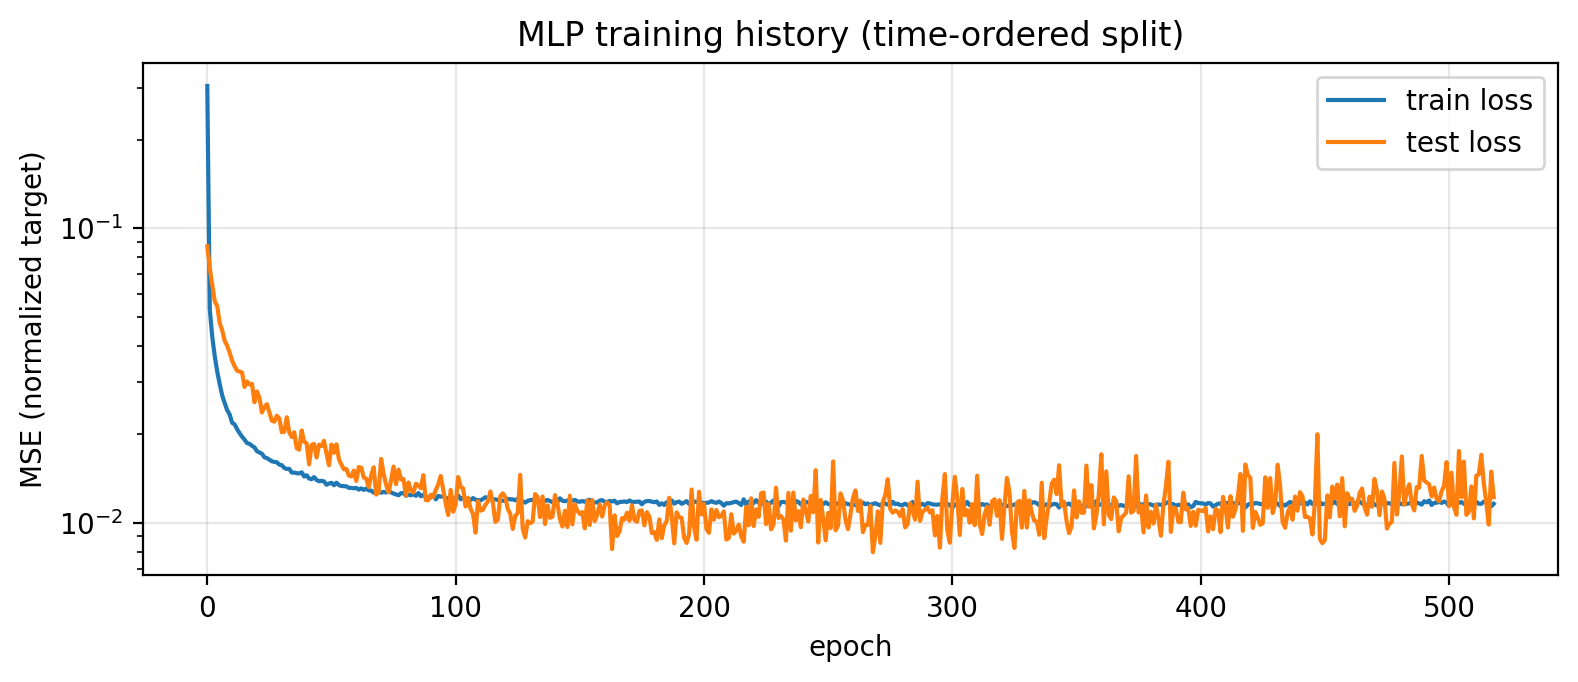

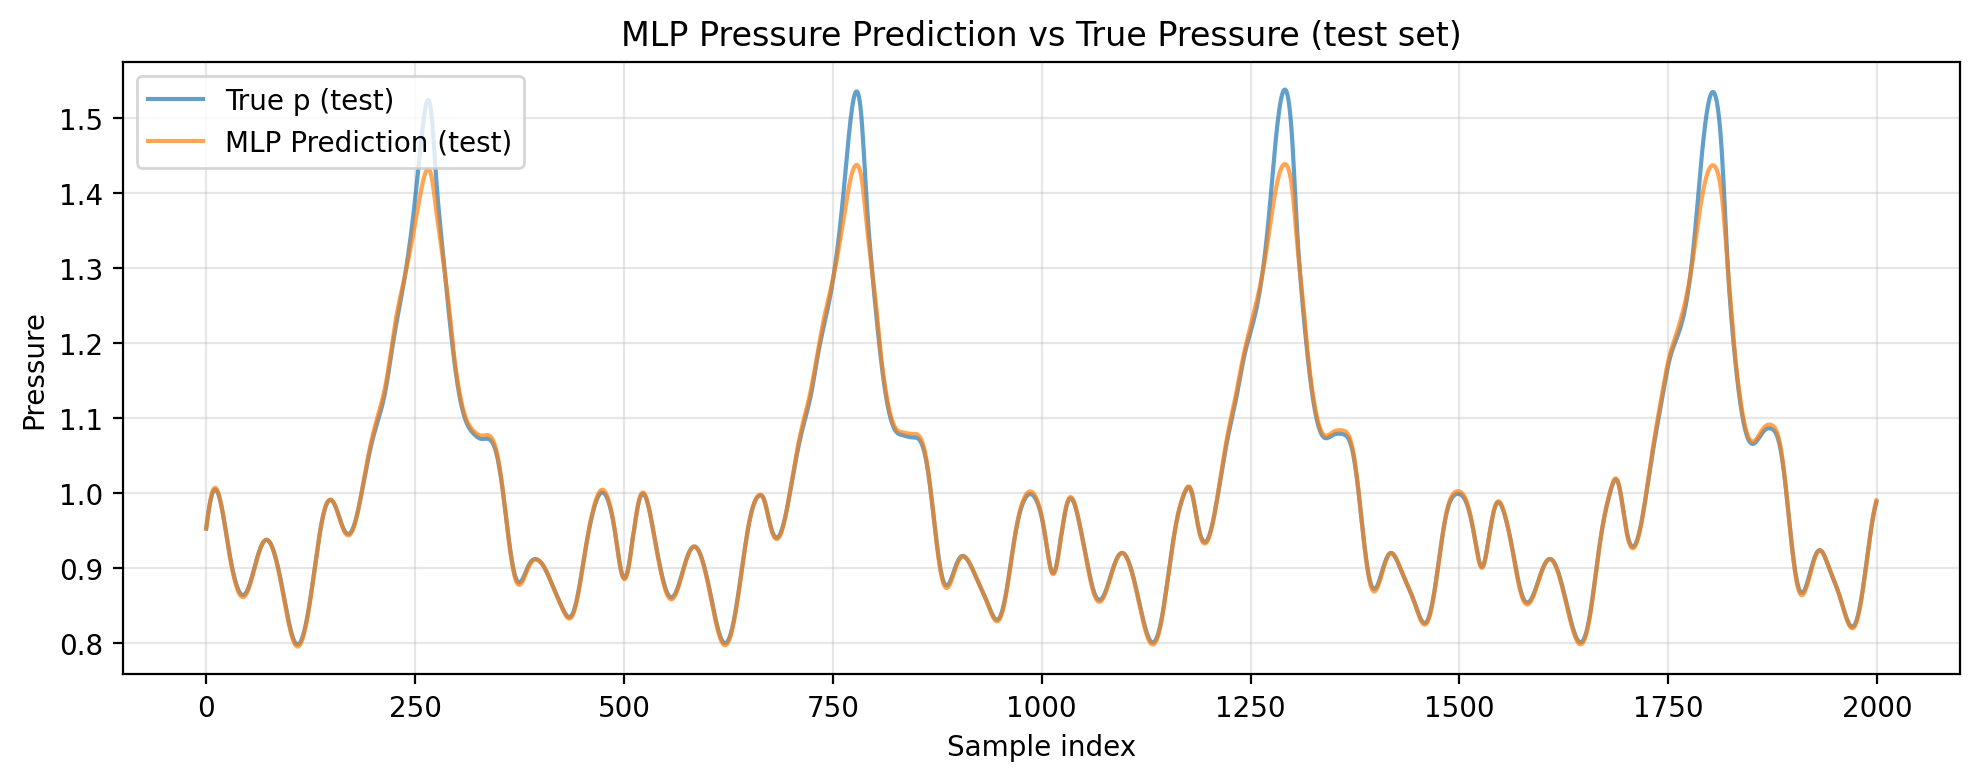

Test RMSE: 1.011805e-02
Test R²: 0.995347


In [25]:
# Prediction diagnostics with normalization-aware inference
if 'ml_model' not in globals() or 'ml_X_test_raw' not in globals():
    print("ML model/test data not found. Run the ML training cell first.")
else:
    plt.figure(figsize=(8, 3.5))
    plt.plot(ml_train_losses, label='train loss')
    plt.plot(ml_test_losses, label='test loss')
    plt.yscale('log')
    plt.xlabel('epoch')
    plt.ylabel('MSE (normalized target)')
    plt.title('MLP training history (time-ordered split)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    p_pred_all = ml_predict_pressure_np(ml_X_test_raw)
    p_true_all = ml_y_test_raw.reshape(-1)

    plt.figure(figsize=(10, 4))
    sample_size = min(2000, len(p_true_all))
    plt.plot(p_true_all[:sample_size], label='True p (test)', alpha=0.7)
    plt.plot(p_pred_all[:sample_size], label='MLP Prediction (test)', alpha=0.7)
    plt.xlabel('Sample index')
    plt.ylabel('Pressure')
    plt.title('MLP Pressure Prediction vs True Pressure (test set)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Test RMSE: {np.sqrt(np.mean((p_pred_all - p_true_all)**2)):.6e}")
    print(f"Test R²: {1 - np.sum((p_pred_all - p_true_all)**2) / np.sum((p_true_all - p_true_all.mean())**2):.6f}")

Plot for rho vs ux, -0.1174 < ux < 0.1017
Plot for rho vs uy, -0.0740 < uy < 0.0836
Plot for rho vs uz, -0.0708 < uz < 0.0662
Plot for rho vs Bx, 0.9841 < Bx < 1.1059
Plot for rho vs By, 0.9363 < By < 1.1034
Plot for rho vs Bz, 0.9249 < Bz < 1.0781


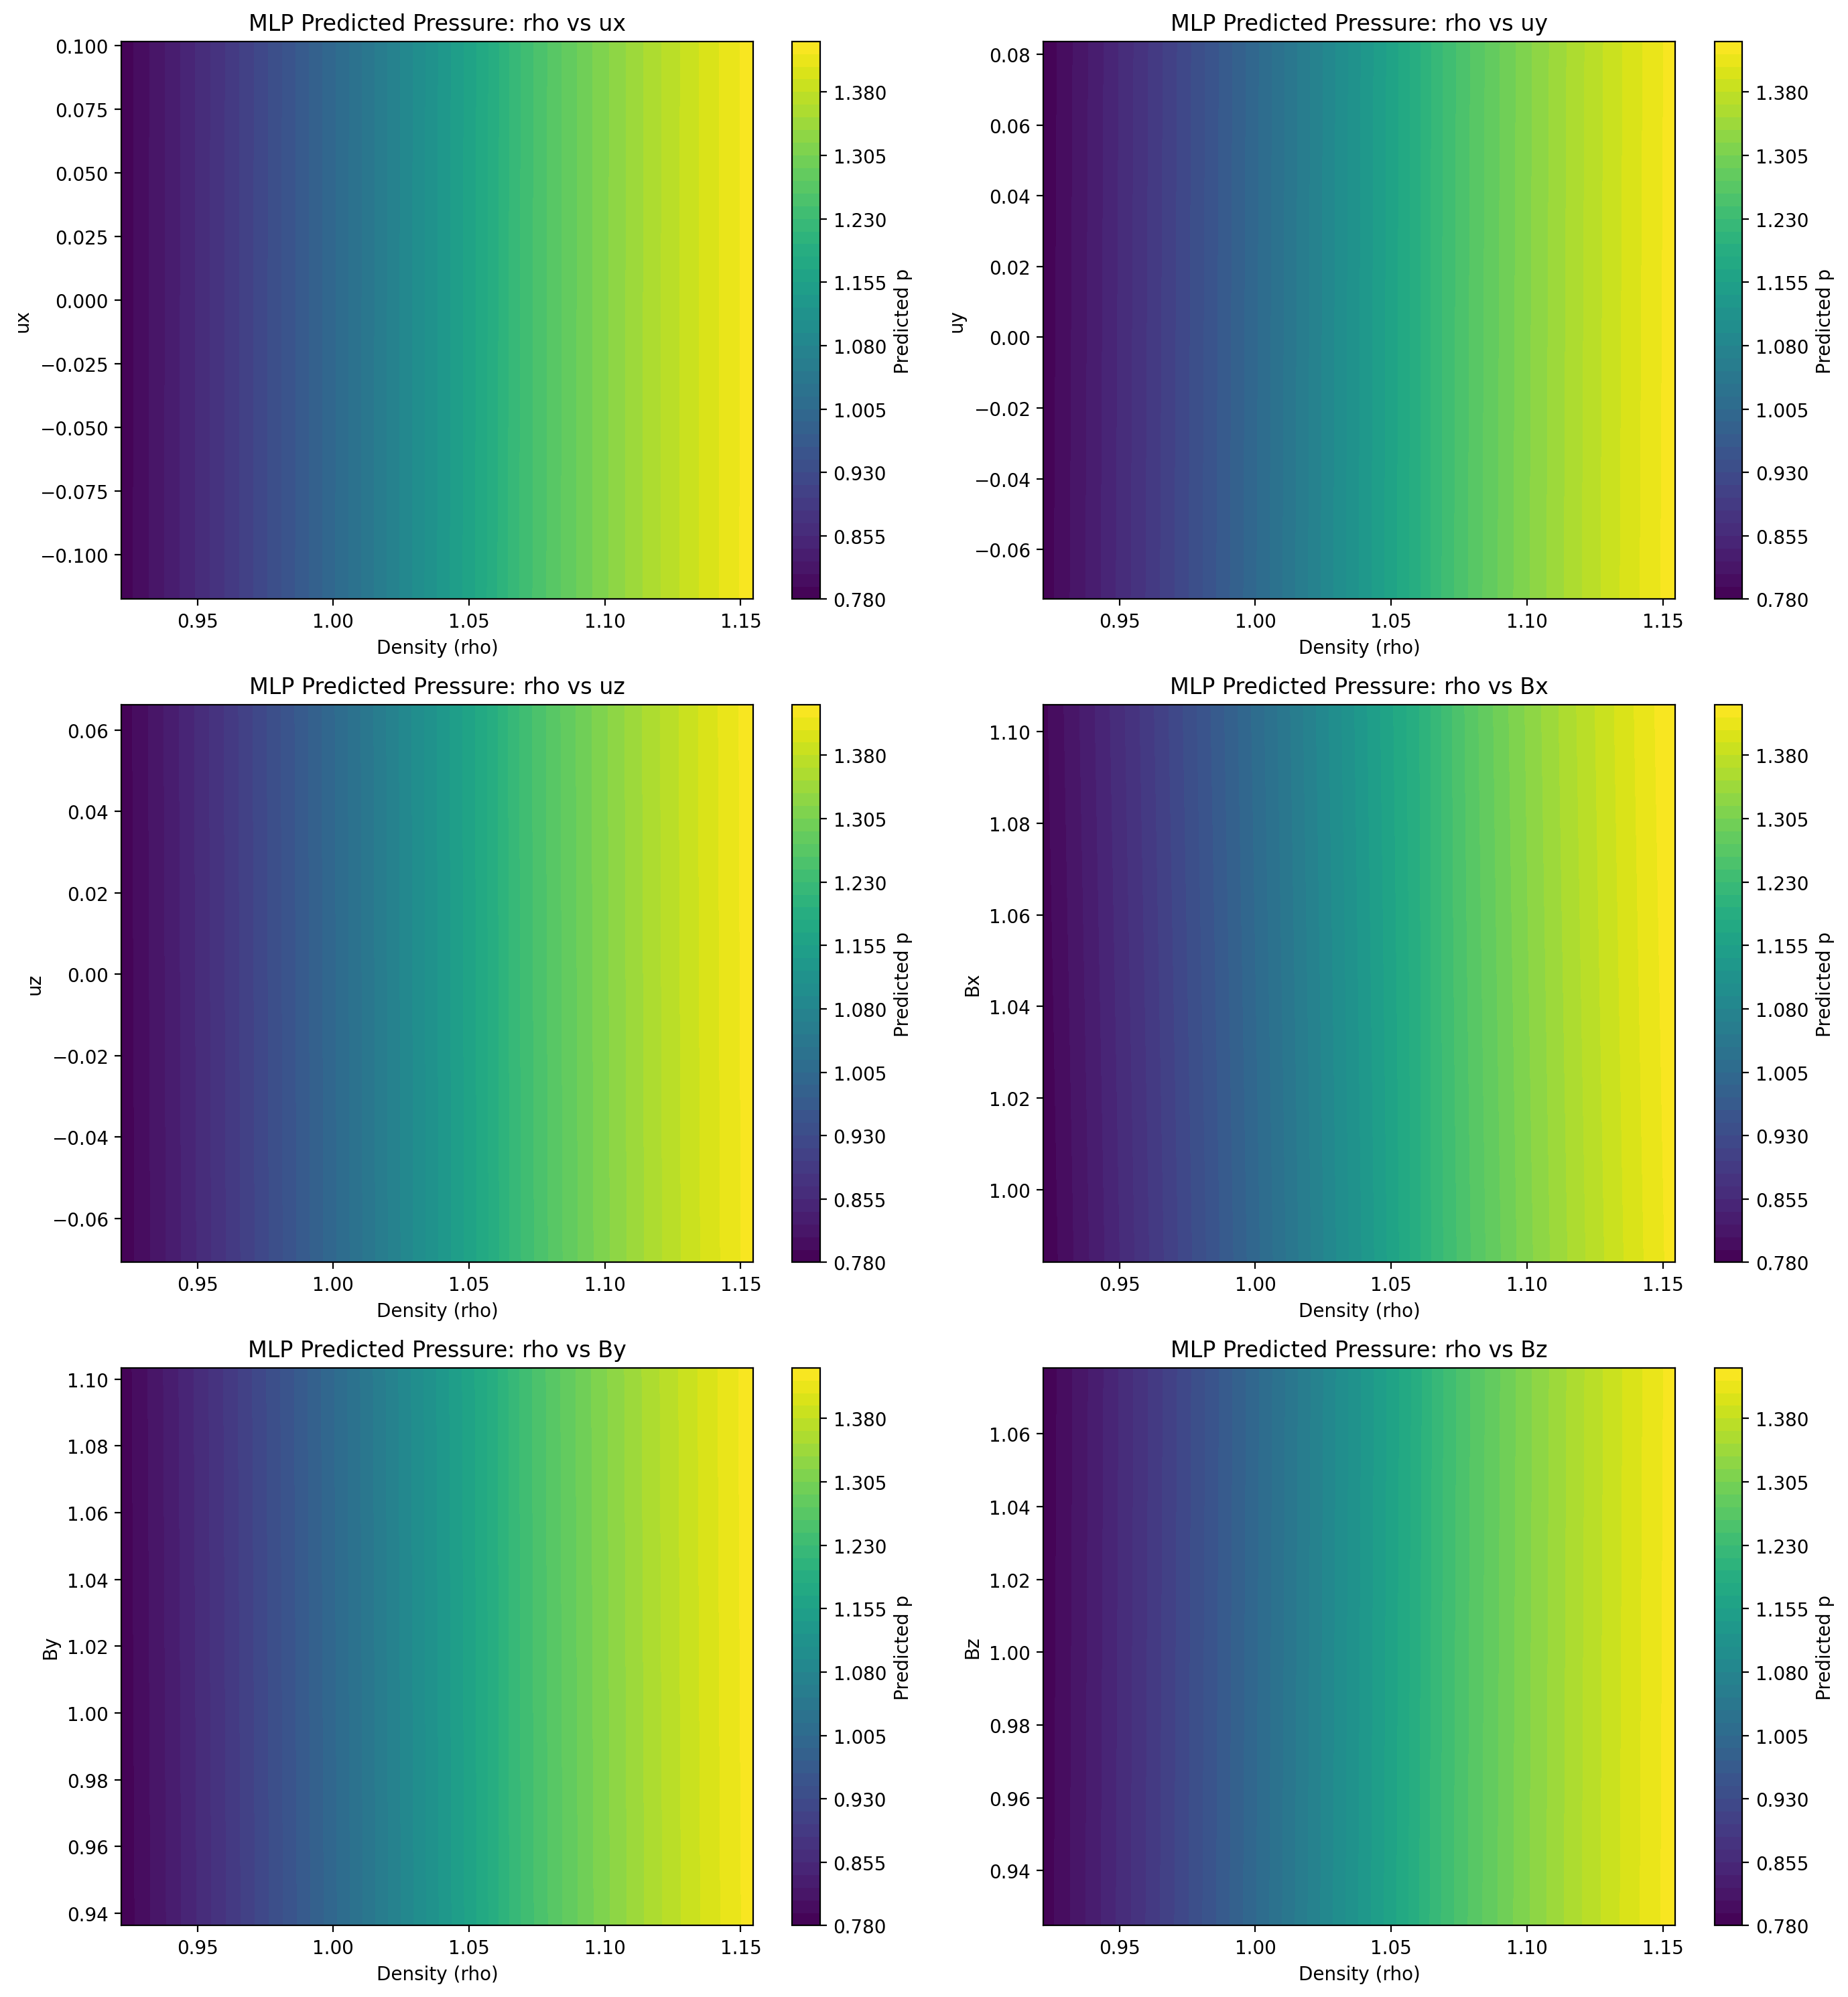

In [26]:
# Feature sensitivity contour plots (rho vs each feature, normalization-aware)
if 'ml_model' not in globals() or 'ml_X_test_raw' not in globals():
    print("ML model/test data not found. Run the ML training cell first.")
else:
    model_inference = ml_model.float().to(ml_device)
    model_inference.eval()

    rho_orig = ml_X_test_raw[:, 0]
    ux_orig = ml_X_test_raw[:, 1]
    uy_orig = ml_X_test_raw[:, 2]
    uz_orig = ml_X_test_raw[:, 3]
    bx_orig = ml_X_test_raw[:, 4]
    by_orig = ml_X_test_raw[:, 5]
    bz_orig = ml_X_test_raw[:, 6]

    rho_space = np.linspace(rho_orig.min(), rho_orig.max(), 100)

    features = ['ux', 'uy', 'uz', 'Bx', 'By', 'Bz']
    feature_arrays = [ux_orig, uy_orig, uz_orig, bx_orig, by_orig, bz_orig]
    feature_indices = [1, 2, 3, 4, 5, 6]

    mean_values = [
        rho_orig.mean(),
        ux_orig.mean(),
        uy_orig.mean(),
        uz_orig.mean(),
        bx_orig.mean(),
        by_orig.mean(),
        bz_orig.mean()
    ]

    n_features = len(features)
    n_rows = (n_features + 1) // 2

    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for idx, (feat_name, feat_array, feat_idx) in enumerate(zip(features, feature_arrays, feature_indices)):
        feat_space = np.linspace(feat_array.min(), feat_array.max(), 100)
        print(f"Plot for rho vs {feat_name}, {feat_space.min():.4f} < {feat_name} < {feat_space.max():.4f}")

        RHO, FEAT = np.meshgrid(rho_space, feat_space)

        input_grid = np.zeros((RHO.size, 7), dtype=np.float32)
        input_grid[:, 0] = RHO.ravel()

        for i in range(1, 7):
            if i == feat_idx:
                input_grid[:, i] = FEAT.ravel()
            else:
                input_grid[:, i] = mean_values[i]

        input_grid_norm = (input_grid - ml_x_mean_np) / ml_x_std_np
        input_grid_t = torch.tensor(input_grid_norm, dtype=torch.float32, device=ml_device)

        with torch.no_grad():
            pred_norm = model_inference(input_grid_t).cpu().numpy().reshape(RHO.shape)
        pred_grid = pred_norm * ml_y_std_np.item() + ml_y_mean_np.item()

        ax = axes[idx]
        contour = ax.contourf(RHO, FEAT, pred_grid, levels=50, cmap='viridis')
        fig.colorbar(contour, ax=ax, label='Predicted p')
        ax.set_xlabel('Density (rho)')
        ax.set_ylabel(f'{feat_name}')
        ax.set_title(f'MLP Predicted Pressure: rho vs {feat_name}')

    if n_features % 2 == 1:
        fig.delaxes(axes[-1])

    plt.tight_layout()
    plt.show()

JACOBIAN ANALYSIS (ML-based closure, normalized model)

Jacobian shape: (7, 7)

Equilibrium state Q0 = [rho, mx, my, mz, Bx, By, Bz]:
[1. 0. 0. 0. 1. 1. 1.]

JACOBIAN MATRIX A0 = dF/dQ:
[[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 3.09929802e+00 -2.91933763e-03 -1.73292080e-02  1.49091071e-02
  -9.18078797e-01  1.01899329e+00  9.77519981e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -1.00000000e+00 -1.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -1.00000000e+00  0.00000000e+00 -1.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00 -1.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -1.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e

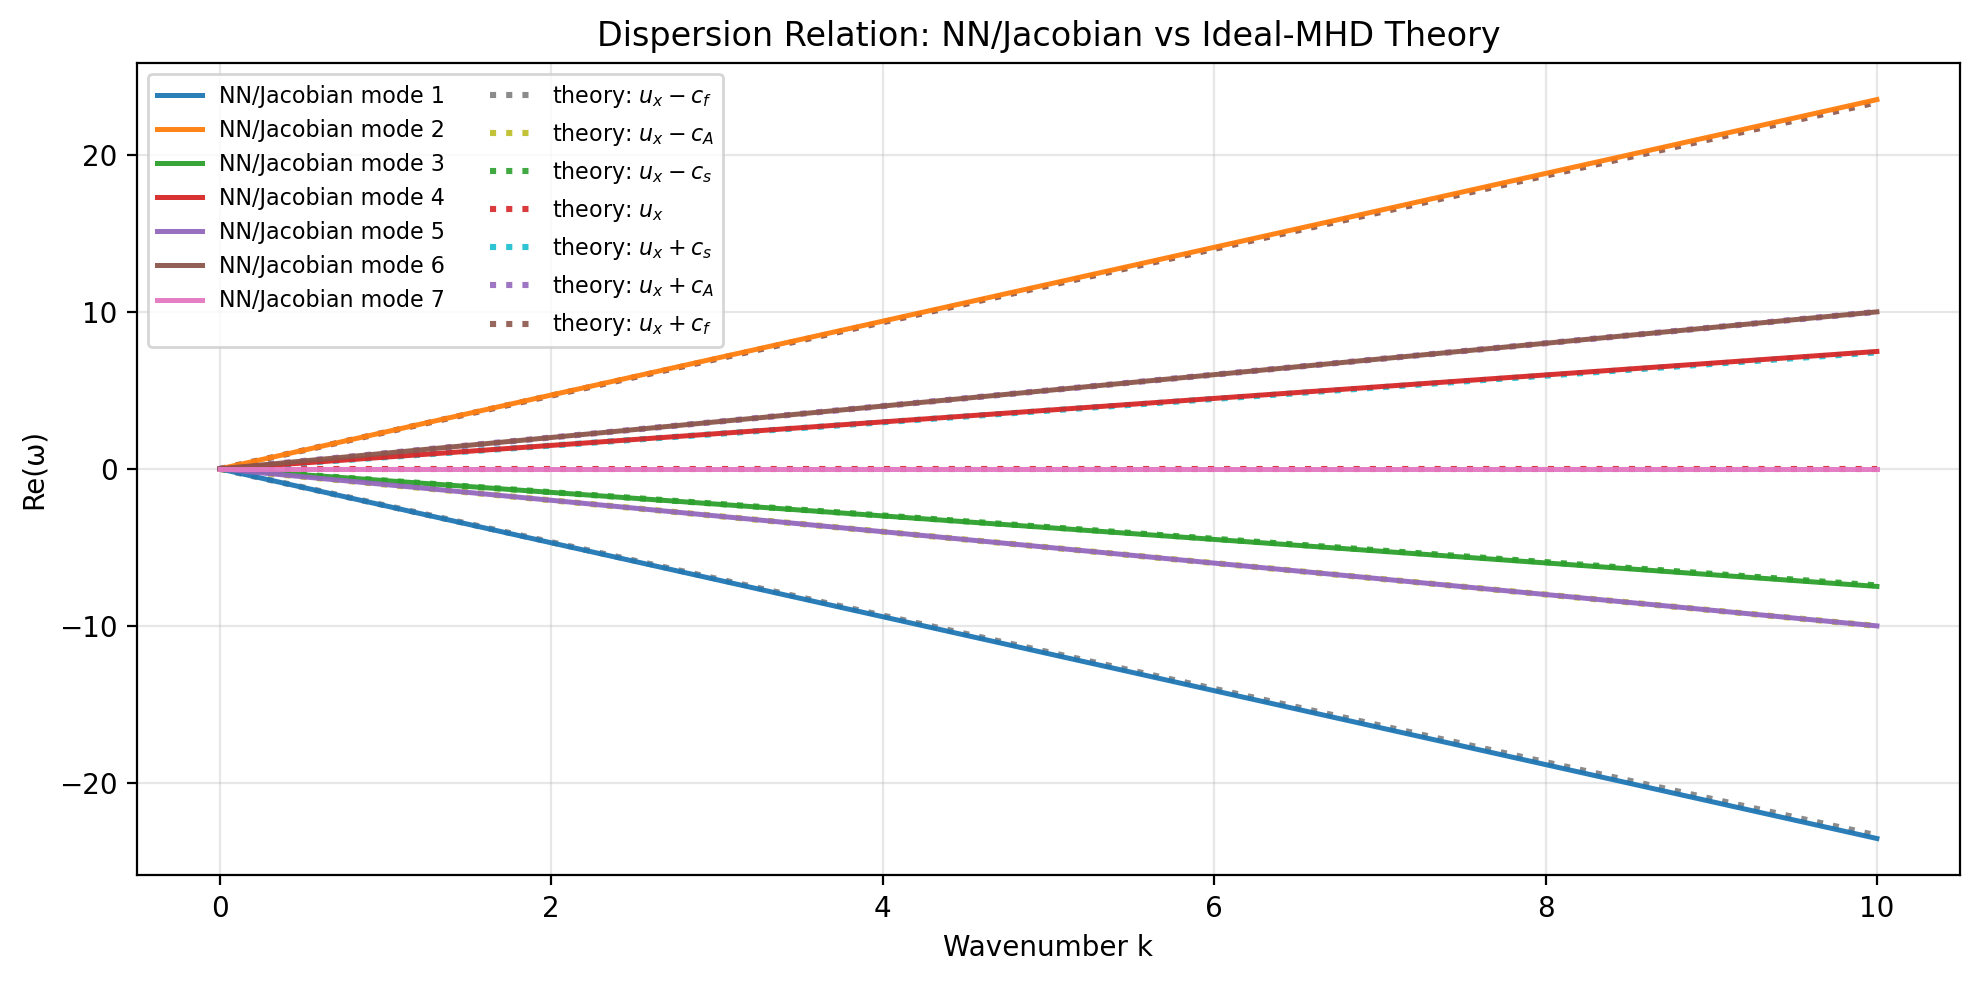

In [30]:
# Dispersion relation from user-chosen equilibrium (normalization-aware Jacobian)

def pressure_nn(rho, u1, u2, u3, B1, B2, B3, net):
    X = torch.stack([rho, u1, u2, u3, B1, B2, B3], dim=-1)

    x_mean = ml_x_mean_t.to(device=X.device, dtype=X.dtype).reshape(-1)
    x_std = ml_x_std_t.to(device=X.device, dtype=X.dtype).reshape(-1)
    y_mean = ml_y_mean_t.to(device=X.device, dtype=X.dtype).reshape(-1)[0]
    y_std = ml_y_std_t.to(device=X.device, dtype=X.dtype).reshape(-1)[0]

    Xn = (X - x_mean) / x_std
    p_norm = net(Xn).squeeze(-1)
    p = p_norm * y_std + y_mean
    return p

def flux_mhd(Q, net):
    rho = Q[0]
    m1 = Q[1]
    m2 = Q[2]
    m3 = Q[3]
    B1 = Q[4]
    B2 = Q[5]
    B3 = Q[6]

    rho_safe = torch.clamp(rho, min=1e-8)
    u1 = m1 / rho_safe
    u2 = m2 / rho_safe
    u3 = m3 / rho_safe

    p = pressure_nn(rho_safe, u1, u2, u3, B1, B2, B3, net)
    Bsq = B1**2 + B2**2 + B3**2
    pmag = 0.5 * Bsq

    F1 = m1
    F2 = m1*u1 + p + pmag - B1*B1
    F3 = m1*u2 - B1*B2
    F4 = m1*u3 - B1*B3
    F5 = u1*B1 - u1*B1
    F6 = u1*B2 - u2*B1
    F7 = u1*B3 - u3*B1
    return torch.stack([F1, F2, F3, F4, F5, F6, F7])

def dispersion_from_jacobian_mhd(rho0, u10, u20, u30, B1_0, B2_0, B3_0, net, ks=None):
    if ks is None:
        ks = [0.1, 1.0, 10.0]

    Q0 = torch.tensor(
        [rho0, rho0*u10, rho0*u20, rho0*u30, B1_0, B2_0, B3_0],
        dtype=torch.double,
        device=ml_device,
        requires_grad=True,
    )

    model_d = net.to(ml_device).double()
    model_d.eval()

    def F_of_Q(Q):
        return flux_mhd(Q, model_d)

    A0 = torch.autograd.functional.jacobian(F_of_Q, Q0)
    eigvals = torch.linalg.eigvals(A0)
    omegas = torch.outer(torch.tensor(ks, dtype=torch.double, device=ml_device), eigvals)

    return A0.detach(), eigvals.detach(), omegas.detach(), Q0.detach()

if 'ml_model' not in globals() or 'ml_x_mean_t' not in globals():
    print("ML model/normalization stats not found. Run the ML training cell first.")
else:
    A0, eigvals, omegas, Q0 = dispersion_from_jacobian_mhd(
        rho0=1.0,
        u10=0.0,
        u20=0.0,
        u30=0.0,
        B1_0=1.0,
        B2_0=1.0,
        B3_0=1.0,
        net=ml_model,
        ks=[0.1, 1.0, 10.0],
    )

    A0_np = A0.cpu().numpy()
    eigvals_np = eigvals.cpu().numpy()

    print("=" * 60)
    print("JACOBIAN ANALYSIS (ML-based closure, normalized model)")
    print("=" * 60)
    print(f"\nJacobian shape: {tuple(A0.shape)}")
    print("\nEquilibrium state Q0 = [rho, mx, my, mz, Bx, By, Bz]:")
    print(Q0.cpu().numpy())

    print("\n" + "=" * 60)
    print("JACOBIAN MATRIX A0 = dF/dQ:")
    print("=" * 60)
    print(A0_np)

    print("\n" + "=" * 60)
    print("EIGENVALUES (characteristic speeds):")
    print("=" * 60)
    print("Real parts (sorted):")
    print(np.sort(np.real(eigvals_np)))
    print("\nImaginary parts:")
    print(np.sort(np.imag(eigvals_np)))
    print(f"\nMax imaginary part: {np.max(np.abs(np.imag(eigvals_np))):.6e}")

    # Theoretical 1D ideal-MHD wave speeds at the same equilibrium state
    rho_eq = float(Q0[0].cpu().numpy())
    mx_eq = float(Q0[1].cpu().numpy())
    Bx_eq = float(Q0[4].cpu().numpy())
    By_eq = float(Q0[5].cpu().numpy())
    Bz_eq = float(Q0[6].cpu().numpy())
    ux_eq = mx_eq / max(rho_eq, 1e-14)

    p_eq = K_adi * (rho_eq ** gamma)
    a2 = gamma * p_eq / max(rho_eq, 1e-14)
    va2 = (Bx_eq**2 + By_eq**2 + Bz_eq**2) / max(rho_eq, 1e-14)
    cax2 = (Bx_eq**2) / max(rho_eq, 1e-14)
    disc = max((a2 + va2)**2 - 4.0 * a2 * cax2, 0.0)

    cf = np.sqrt(0.5 * ((a2 + va2) + np.sqrt(disc)))
    cs = np.sqrt(0.5 * ((a2 + va2) - np.sqrt(disc)))
    ca = np.sqrt(cax2)

    theory_speeds = np.array([
        ux_eq - cf, ux_eq - ca, ux_eq - cs, ux_eq, ux_eq + cs, ux_eq + ca, ux_eq + cf
    ])
    theory_labels = [
        r'theory: $u_x-c_f$', r'theory: $u_x-c_A$', r'theory: $u_x-c_s$',
        r'theory: $u_x$', r'theory: $u_x+c_s$', r'theory: $u_x+c_A$', r'theory: $u_x+c_f$'
    ]

    print("\nTheoretical 1D ideal-MHD characteristic speeds (sorted):")
    print(np.sort(theory_speeds))

    # Deterministic mode-matching error (sorted real parts)
    eig_sorted = np.sort(np.real(eigvals_np))
    th_sorted = np.sort(theory_speeds)
    abs_err = np.abs(eig_sorted - th_sorted)
    # Safe relative scale: avoid division blow-up on the ~0 entropy/contact mode
    rel_scale = np.maximum(np.abs(th_sorted), 1e-8)
    rel_err = abs_err / rel_scale

    print("\nMode-by-mode error (sorted branches):")
    print("  idx | numerical | theory | abs err | rel err")
    for idx, (numv, thv, ae, re) in enumerate(zip(eig_sorted, th_sorted, abs_err, rel_err), start=1):
        print(f"  {idx:>3d} | {numv:>+9.6f} | {thv:>+9.6f} | {ae:>8.3e} | {re:>8.3e}")

    print(f"\nMean relative error: {np.mean(rel_err):.3e}")
    print(f"Max  relative error: {np.max(rel_err):.3e}")
    print("Note: this comparison is deterministic (no uncertainty model included).")

    ks_plot = np.linspace(0, 10, 200)
    omega_plot = np.outer(ks_plot, eigvals_np)

    fig, ax = plt.subplots(figsize=(10, 5))
    for j in range(omega_plot.shape[1]):
        ax.plot(
            ks_plot, np.real(omega_plot[:, j]),
            lw=1.8, alpha=0.95, zorder=3,
            label=f'NN/Jacobian mode {j+1}'
        )

    # Overlay theoretical branches with distinct colors + ':' style
    theory_colors = ['tab:gray', 'tab:olive', 'tab:green', 'tab:red', 'tab:cyan', 'tab:purple', 'tab:brown']
    for speed, label, color in zip(theory_speeds, theory_labels, theory_colors):
        ax.plot(
            ks_plot, ks_plot * speed,
            linestyle=':', color=color, lw=2.2, alpha=0.9, zorder=2,
            label=label
        )

    ax.set_xlabel('Wavenumber k')
    ax.set_ylabel('Re(ω)')
    ax.set_title('Dispersion Relation: NN/Jacobian vs Ideal-MHD Theory')
    ax.grid(alpha=0.3)
    ax.legend(loc='best', ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

# Linear dispersion relations in ideal MHD (uniform plasma)

Assume a uniform equilibrium with constant density `ρ0`, pressure `p0`, magnetic field `B0`, and no flow.
Take plane-wave perturbations

$$
\delta(\cdot)\propto \exp\!\left(i(\mathbf{k}\cdot\mathbf{x}-\omega t)\right).
$$

Define

$$
c_s^2=\gamma p_0/\rho_0,\qquad
v_A^2=\frac{B_0^2}{\mu_0\rho_0},\qquad
k_\parallel = k\cos\theta,
$$

where `θ` is the angle between `k` and `B0`.

---

## Alfvén mode

$$
\boxed{\ \omega^2 = k_\parallel^2\, v_A^2 = k^2 v_A^2 \cos^2\theta\ }
$$

---

## Magnetosonic modes (fast/slow)

They satisfy the quartic:

$$
\boxed{\ \omega^4 - k^2(c_s^2+v_A^2)\,\omega^2 + k^4 c_s^2 v_A^2 \cos^2\theta = 0\ }
$$

Equivalently, with phase speed \(v_{\rm ph}=\omega/k\):

$$
\boxed{\ v_{\rm ph}^2
= \frac{1}{2}\Big[(c_s^2+v_A^2)\ \pm\ \sqrt{(c_s^2+v_A^2)^2 - 4 c_s^2 v_A^2 \cos^2\theta}\Big]\ }
$$

- “+” : **fast** magnetosonic
- “−” : **slow** magnetosonic

---

## Special cases

### Parallel propagation $(\theta=0)$

$$
\omega^2 = k^2 v_A^2 \quad(\text{Alfvén}),
$$
$$
\omega^2 = k^2 c_s^2,\qquad
\omega^2 = k^2 v_A^2 \quad(\text{magnetosonic branches}).
$$

### Perpendicular propagation $(\theta=\pi/2)$

$$
\omega^2 = 0 \quad(\text{Alfvén; no propagation}),
$$
$$
\omega^2 = k^2(c_s^2+v_A^2) \quad(\text{fast}),
$$
$$
\omega^2 = 0 \quad(\text{slow; nonpropagating}).
$$